
#**PROBAR CON FEATURES COMBINADAS**
#**GRAFICOS EN INGLES!!!**

#**CELDA 0 — Setup + parámetros (incluye muestreo)**

#**OJO QUE EL MUESTREO ES EN CARACTERES Y POR AHI SON POCAS SENTENCIAS PARA LOS MODELOS BERT**

In [ ]:
import psutil
import os
import shutil

# Función para convertir a GB
def format_gb(bytes_value):
    return f"{bytes_value / 1e9:.2f} GB"

# 1. Información de la CPU (detallada)
print("=== INFORMACIÓN DETALLADA DE LA CPU ===")
with open("/proc/cpuinfo", "r") as f:
    cpuinfo = f.read()

# Mostrar solo una vez por procesador (evita repetidos si hay varios núcleos)
cpus = [block for block in cpuinfo.strip().split("\n\n")]
if cpus:
    cpu_lines = cpus[0].split("\n")
    for line in cpu_lines:
        if any(key in line for key in ["model name", "vendor_id", "cpu MHz", "cache size", "flags"]):
            print(line)
print(f"Núcleos físicos: {psutil.cpu_count(logical=False)}")
print(f"Núcleos lógicos: {psutil.cpu_count(logical=True)}")
print()

# 2. Memoria RAM
mem = psutil.virtual_memory()
print("=== MEMORIA RAM ===")
print(f"Total:      {format_gb(mem.total)}")
print(f"Usada:      {format_gb(mem.used)}")
print(f"Disponible: {format_gb(mem.available)}")
print()

# 3. Espacio en disco
total, used, free = shutil.disk_usage("/")
print("=== ESPACIO EN DISCO ===")
print(f"Total:      {format_gb(total)}")
print(f"Usado:      {format_gb(used)}")
print(f"Disponible: {format_gb(free)}")
print()

# 4. GPU (si está disponible)
print("=== GPU ===")
try:
    import torch
    if torch.cuda.is_available():
        print(f"GPU detectada: {torch.cuda.get_device_name(0)}")
    else:
        print("No se detectó GPU.")
except ImportError:
    print("Torch no está instalado. No se puede verificar la GPU.")


=== INFORMACIÓN DETALLADA DE LA CPU ===
vendor_id	: GenuineIntel
model name	: Intel(R) Xeon(R) CPU @ 2.20GHz
cpu MHz		: 2200.230
cache size	: 39424 KB
flags		: fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht syscall nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xtopology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt aes xsave avx f16c rdrand hypervisor lahf_lm abm 3dnowprefetch ssbd ibrs ibpb stibp ibrs_enhanced fsgsbase tsc_adjust bmi1 hle avx2 smep bmi2 erms invpcid rtm mpx avx512f avx512dq rdseed adx smap clflushopt clwb avx512cd avx512bw avx512vl xsaveopt xsavec xgetbv1 xsaves arat avx512_vnni md_clear arch_capabilities
Núcleos físicos: 6
Núcleos lógicos: 12

=== MEMORIA RAM ===
Total:      179.37 GB
Usada:      17.73 GB
Disponible: 159.98 GB

=== ESPACIO EN DISCO ===
Total:      253.06 GB
Usado:      48.86 GB
Disponible: 204.18 GB

=== GPU ===
GPU detectada: NVIDIA A100

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

BASE    = Path("/content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria")
TXT_DIR = BASE / "Datos_SEDICI/SEDICI_FullText_TXT"
MAP_CSV = BASE / "Mapeo_SEDICI_Rafa_data-1758643353469.csv"
META_CSV= BASE / "SEDICIpoblacion.csv"

OUT_DIR = BASE / "outputs_fulltext_clf"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# PARAMETROS IMPORTANTES
# =========================
TOP_K_LABELS = 37
MIN_SUPPORT  = 5

# para que sea viable leer fulltext, se lee SOLO un muestreo de handles
TARGET_N_HANDLES = 20000      # None = usar todos (no recomendado si querés velocidad)
SAMPLE_BUFFER    = 3000       # para compensar handles con TXT vacío/errores (se recorta a TARGET_N al final)
SAMPLE_METHOD    = "stratified"  # "stratified" (recomendado) o "random"
SAMPLE_SEED      = 42

# fulltext
MAX_FULLTEXT_CHARS = 100000
MAX_WORKERS_TXT    = 16        # threads para lectura I/O

# split
RANDOM_STATE = 42
TEST_SIZE = 0.15
VAL_SIZE  = 0.15
MAX_TRIES_SPLIT = 40           # reintentos para intentar que todas las labels estén en train/val/test

# vectorizadores
MAX_FEATURES = 100000
NGRAM_RANGE = (1, 2)

# BM25 (estándar)
BM25_K1 = 1.5
BM25_B  = 0.75

# ejecuciones separadas por run
RUN_TAG = f"n{TARGET_N_HANDLES or 'ALL'}_top{TOP_K_LABELS}_min{MIN_SUPPORT}_seed{SAMPLE_SEED}"
OUT_RUN = OUT_DIR / RUN_TAG
OUT_RUN.mkdir(parents=True, exist_ok=True)

print("BASE    :", BASE)
print("TXT_DIR :", TXT_DIR)
print("MAP_CSV :", MAP_CSV)
print("META_CSV:", META_CSV)
print("OUT_DIR :", OUT_DIR)
print("OUT_RUN :", OUT_RUN)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE    : /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria
TXT_DIR : /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/Datos_SEDICI/SEDICI_FullText_TXT
MAP_CSV : /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/Mapeo_SEDICI_Rafa_data-1758643353469.csv
META_CSV: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/SEDICIpoblacion.csv
OUT_DIR : /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/outputs_fulltext_clf
OUT_RUN : /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/outputs_fulltext_clf/n20000_top37_min5_seed42


#**CELDA 1 — TXT→handle (rápido) SIN leer fulltext**

In [ ]:
import pandas as pd

OUT_TXT2HANDLE = OUT_RUN / "txt_to_handle.csv"
OUT_STATS_MAP  = OUT_RUN / "mapping_fast_stats.csv"

# 1) Listar TXT
txt_files = sorted([p for p in TXT_DIR.glob("*.txt") if p.is_file()])
df_txt = pd.DataFrame({
    "txt_filename": [p.name for p in txt_files],
    "file_id":      [p.stem for p in txt_files],
    "txt_path":     [str(p) for p in txt_files],
})
print("TXT encontrados:", len(df_txt))

# 2) Cargar mapeo Rafa
map_df = pd.read_csv(MAP_CSV, dtype=str, low_memory=False)
map_df.columns = [c.strip() for c in map_df.columns]

handle_col = next((c for c in map_df.columns if c.strip().lower() == "handle"), None)
if handle_col is None:
    raise ValueError("No encontré columna 'handle' en MAP_CSV.")

id_candidates = [c for c in map_df.columns if c.strip().lower() in ("internal_id","internalid","file_id","id","bitstream_id")]
if not id_candidates:
    id_candidates = [c for c in map_df.columns if ("id" in c.lower()) and (c.lower() != handle_col.lower())]
if not id_candidates:
    raise ValueError("No pude detectar columna ID en el mapeo Rafa (ej. internal_id).")

id_col = id_candidates[0]
print("Usando columnas del mapeo Rafa:")
print(" - id_col    :", id_col)
print(" - handle_col:", handle_col)

map_small = map_df[[id_col, handle_col]].copy()
map_small[id_col] = map_small[id_col].fillna("").astype(str).str.strip()
map_small[handle_col] = map_small[handle_col].fillna("").astype(str).str.strip()
map_small = map_small.drop_duplicates(subset=[id_col], keep="first")

# 3) Merge TXT -> handle
df_map = df_txt.merge(map_small, left_on="file_id", right_on=id_col, how="left").drop(columns=[id_col])
df_map.rename(columns={handle_col: "handle"}, inplace=True)
df_map["handle"] = df_map["handle"].replace({"": None, "nan": None})
df_map["handle_url"] = df_map["handle"].apply(lambda h: f"https://sedici.unlp.edu.ar/handle/{h}" if isinstance(h,str) and h else None)

df_map.to_csv(OUT_TXT2HANDLE, index=False, encoding="utf-8")
print("Guardado:", OUT_TXT2HANDLE)

n_txt = len(df_map)
n_mapped = int(df_map["handle"].notna().sum())
n_handles = int(df_map["handle"].dropna().nunique())

stats = pd.DataFrame([{
    "txt_files_total": n_txt,
    "txt_files_with_handle": n_mapped,
    "handles_with_any_txt": n_handles,
    "pct_txt_mapped": (n_mapped / n_txt * 100) if n_txt else 0.0,
}])
stats.to_csv(OUT_STATS_MAP, index=False, encoding="utf-8")
print("Stats guardado:", OUT_STATS_MAP)
stats


TXT encontrados: 151836
Usando columnas del mapeo Rafa:
 - id_col    : internal_id
 - handle_col: handle
Guardado: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/outputs_fulltext_clf/n20000_top37_min5_seed42/txt_to_handle.csv
Stats guardado: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/outputs_fulltext_clf/n20000_top37_min5_seed42/mapping_fast_stats.csv


,txt_files_total,txt_files_with_handle,handles_with_any_txt,pct_txt_mapped
0,151836,147192,139793,96.941437


#**CELDA 2 — Cobertura + frecuencias + TOP labels + muestreo ANTES de leer fulltext**

Handles con al menos 1 TXT (sin leerlo): 139793
Label cols: ['sedici.subject.materias', 'sedici.subject.materias[]', 'sedici.subject.materias[es]', 'sedici.subject.other[es]']
Abstract cols: ['dc.description.abstract', 'dc.description.abstract[]', 'dc.description.abstract[de]', 'dc.description.abstract[en]', 'dc.description.abstract[es]'] ...
dc.subject cols: ['dc.subject', 'dc.subject[]', 'dc.subject[de]', 'dc.subject[en]', 'dc.subject[es]'] ...
URI cols: ['dc.identifier.uri', 'dc.identifier.uri[]', 'dc.identifier.uri[es]', 'sedici.identifier.uri[]', 'sedici.identifier.uri[es]'] ...


Metadata scan (cobertura + labels): 0it [00:00, ?it/s]


=== COBERTURA PRE (antes de leer fulltext) ===


,meta_rows_total,meta_rows_with_handle,meta_rows_with_handle_and_txt,unique_handles_in_meta,unique_handles_with_txt,rows_cov_txt_over_handle_%,handles_cov_txt_over_all_%
0,126080,126077,103434,126077,103434,82.04034,82.04034


Guardado: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/outputs_fulltext_clf/n20000_top37_min5_seed42/coverage_pre_fulltext.csv
Frecuencias guardadas: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/outputs_fulltext_clf/n20000_top37_min5_seed42/label_frequencies_pre_fulltext.csv


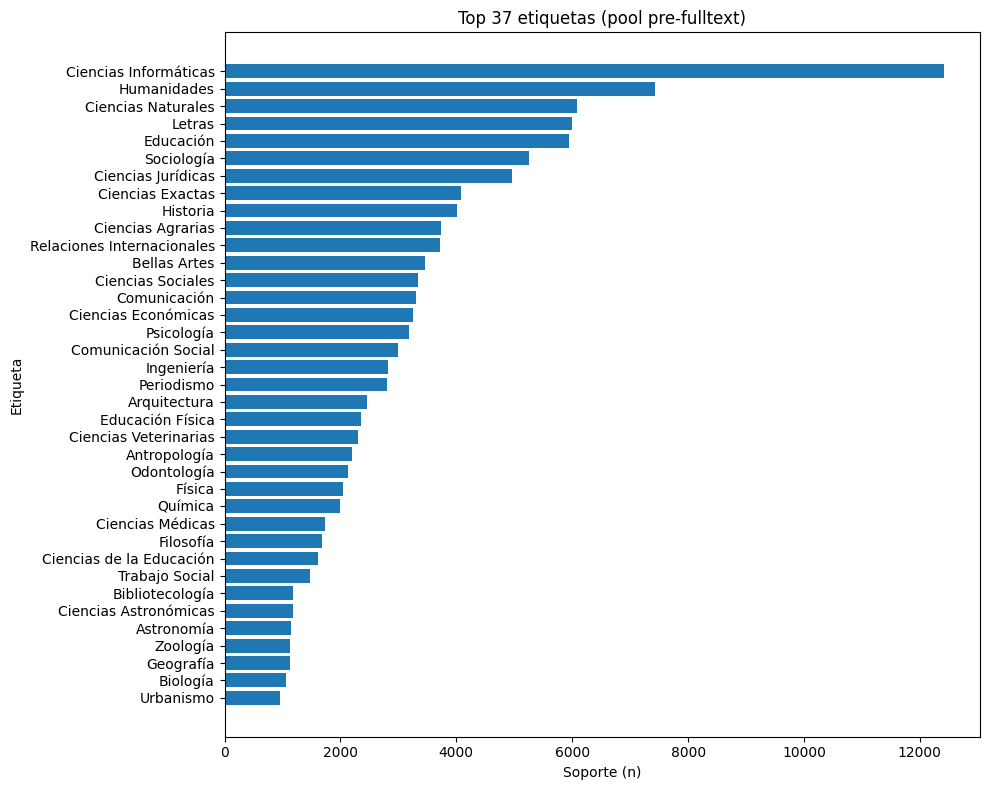

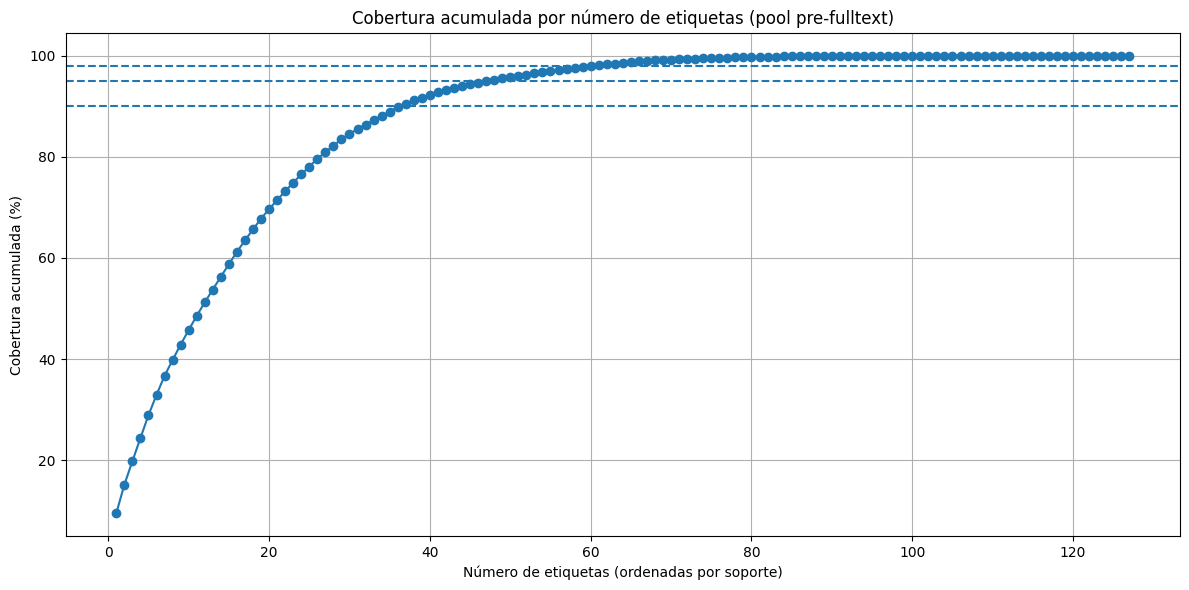


TOP_K_LABELS=37 | MIN_SUPPORT=5 | labels seleccionadas=37
Pool (handles) guardado: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/outputs_fulltext_clf/n20000_top37_min5_seed42/pool_handles_pre_fulltext.csv
Pool handles (post TOP-K): 95885
Muestreo: target=20000 + buffer=3000 => draw=23000
Sample handles guardado: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/outputs_fulltext_clf/n20000_top37_min5_seed42/sampled_handles_pre_fulltext.csv
Sample handles: 23009


,handle,abstract_text,keywords_text,labels
0,10915/100001,The main objective of this work was to develop...,Interface tension||Proteins||Kinetic model,[Química]
1,10915/100003,"A new species of the Palpomyia tibialis group,...",Peru||Ceratopogonidae||Palpomyia ryszardi||New...,[Ciencias Naturales]
2,10915/100018,La ponencia abarca los debates que circulan al...,No mataras||Violencia::http://vocabularies.une...,[Sociología]
3,10915/100020,Objetivo del proyecto: Estudiar el rol de los ...,Educación Superior::UIa05c4426::600||Investiga...,[Ciencias Informáticas]
4,10915/100021,Objetivo del proyecto: Analizar diferencias pa...,Investigación Científica y Desarrollo Tecnológ...,[Ciencias Informáticas]


In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from tqdm.auto import tqdm
from IPython.display import display

OUT_COVERAGE_PRE   = OUT_RUN / "coverage_pre_fulltext.csv"
OUT_FREQ_LABELS    = OUT_RUN / "label_frequencies_pre_fulltext.csv"
OUT_POOL_HANDLES   = OUT_RUN / "pool_handles_pre_fulltext.csv"
OUT_SAMPLE_HANDLES = OUT_RUN / "sampled_handles_pre_fulltext.csv"

df_map = pd.read_csv(OUT_RUN / "txt_to_handle.csv", dtype=str)
df_map["handle"] = df_map["handle"].replace({"": None, "nan": None})
handles_with_txt = set(df_map["handle"].dropna().astype(str).tolist())
print("Handles con al menos 1 TXT (sin leerlo):", len(handles_with_txt))

# detectar columnas metadata
header = pd.read_csv(META_CSV, nrows=0, low_memory=False)
cols = [c.strip() for c in header.columns]

label_columns = [
    'sedici.subject.materias',
    'sedici.subject.materias[]',
    'sedici.subject.materias[es]',
    'sedici.subject.other[es]'
]
label_columns = [c for c in label_columns if c in cols]

abstract_cols = [c for c in cols if "abstract" in c.lower()]
subject_cols  = [c for c in cols if "dc.subject" in c.lower()]

uri_cols = [c for c in cols if "identifier.uri" in c.lower() or c.strip().lower() == "handle" or c.strip().lower().endswith(".uri")]

usecols = sorted(set(label_columns + abstract_cols + subject_cols + uri_cols))
if not usecols:
    raise ValueError("No pude determinar columnas a leer desde metadata.")

print("Label cols:", label_columns)
print("Abstract cols:", abstract_cols[:5], ("..." if len(abstract_cols)>5 else ""))
print("dc.subject cols:", subject_cols[:5], ("..." if len(subject_cols)>5 else ""))
print("URI cols:", uri_cols[:5], ("..." if len(uri_cols)>5 else ""))

HANDLE_RE = re.compile(r"(10915/\d+)")

def extract_handle_vectorized(chunk: pd.DataFrame) -> pd.Series:
    if "handle" in chunk.columns:
        s = chunk["handle"].fillna("").astype(str).str.strip()
        s = s.where(s != "", None)
        if uri_cols:
            mask = s.isna()
            if mask.any():
                concat = chunk.loc[mask, uri_cols].fillna("").astype(str).agg(" ".join, axis=1)
                s.loc[mask] = concat.str.extract(HANDLE_RE, expand=False)
        return s
    if not uri_cols:
        return pd.Series([None]*len(chunk), index=chunk.index)
    concat = chunk[uri_cols].fillna("").astype(str).agg(" ".join, axis=1)
    return concat.str.extract(HANDLE_RE, expand=False)

def join_cols_vectorized(chunk: pd.DataFrame, cols_list: list) -> pd.Series:
    if not cols_list:
        return pd.Series([""]*len(chunk), index=chunk.index)
    s = chunk[cols_list].fillna("").astype(str).agg(" ".join, axis=1)
    return s.str.replace(r"\s+", " ", regex=True).str.strip()

def parse_labels_from_row_values(row_vals) -> list:
    labs = []
    for v in row_vals:
        if not v:
            continue
        for part in str(v).split("||"):
            part = part.strip()
            if part:
                labs.append(part.split("::")[0].strip())
    return sorted(set([x for x in labs if x]))

chunksize = 50000
counter = Counter()

meta_rows_total = 0
meta_rows_with_handle = 0
meta_rows_with_txt_handle = 0
unique_handles_all = set()
unique_handles_with_txt = set()

meta_rows = []

for chunk in tqdm(pd.read_csv(META_CSV, usecols=usecols, dtype=str, low_memory=False, chunksize=chunksize),
                  desc="Metadata scan (cobertura + labels)"):
    chunk = chunk.copy()
    chunk.columns = [c.strip() for c in chunk.columns]
    meta_rows_total += len(chunk)

    chunk["handle"] = extract_handle_vectorized(chunk)
    has_handle = chunk["handle"].notna()
    meta_rows_with_handle += int(has_handle.sum())

    handles_here = chunk.loc[has_handle, "handle"].astype(str)
    unique_handles_all.update(handles_here.tolist())

    in_txt = has_handle & chunk["handle"].astype(str).isin(handles_with_txt)
    meta_rows_with_txt_handle += int(in_txt.sum())
    unique_handles_with_txt.update(chunk.loc[in_txt, "handle"].astype(str).tolist())

    # pool solo con handles que tienen TXT
    chunk = chunk[in_txt].copy()
    if len(chunk) == 0:
        continue

    # textos (sin fulltext aún)
    chunk["abstract_text"] = join_cols_vectorized(chunk, abstract_cols)
    chunk["keywords_text"] = join_cols_vectorized(chunk, subject_cols)

    # labels
    if label_columns:
        vals = chunk[label_columns].fillna("").astype(str).values
        labs = [parse_labels_from_row_values(v) for v in vals]
    else:
        labs = [[] for _ in range(len(chunk))]
    chunk["labels"] = labs

    for labs_i in labs:
        counter.update(labs_i)

    meta_rows.append(chunk[["handle","abstract_text","keywords_text","labels"]])

meta = pd.concat(meta_rows, ignore_index=True) if meta_rows else pd.DataFrame(columns=["handle","abstract_text","keywords_text","labels"])

coverage_pre = pd.DataFrame([{
    "meta_rows_total": meta_rows_total,
    "meta_rows_with_handle": meta_rows_with_handle,
    "meta_rows_with_handle_and_txt": meta_rows_with_txt_handle,
    "unique_handles_in_meta": len(unique_handles_all),
    "unique_handles_with_txt": len(unique_handles_with_txt),
    "rows_cov_txt_over_handle_%": (meta_rows_with_txt_handle / meta_rows_with_handle * 100) if meta_rows_with_handle else 0.0,
    "handles_cov_txt_over_all_%": (len(unique_handles_with_txt) / len(unique_handles_all) * 100) if unique_handles_all else 0.0,
}])

print("\n=== COBERTURA PRE (antes de leer fulltext) ===")
display(coverage_pre)
coverage_pre.to_csv(OUT_COVERAGE_PRE, index=False, encoding="utf-8")
print("Guardado:", OUT_COVERAGE_PRE)

# agregar por handle (pool)
def agg_join_unique(series):
    xs = [str(x).strip() for x in series if isinstance(x,str) and str(x).strip()]
    seen = set()
    out = []
    for x in xs:
        if x not in seen:
            out.append(x); seen.add(x)
    return " ".join(out).strip()

def agg_union_labels(series):
    s = set()
    for x in series:
        if isinstance(x, list):
            s.update(x)
    return sorted(s)

pool = (meta.groupby("handle", as_index=False)
        .agg({"abstract_text": agg_join_unique,
              "keywords_text": agg_join_unique,
              "labels": agg_union_labels}))

# frecuencias etiquetas en el pool
freq_df = pd.DataFrame(counter.most_common(), columns=["label","support"])
if len(freq_df):
    freq_df["pct"] = freq_df["support"] / freq_df["support"].sum() * 100
    freq_df["cum_support"] = freq_df["support"].cumsum()
    freq_df["cum_pct"] = freq_df["cum_support"] / freq_df["support"].sum() * 100
freq_df.to_csv(OUT_FREQ_LABELS, index=False, encoding="utf-8")
print("Frecuencias guardadas:", OUT_FREQ_LABELS)

# plots
if len(freq_df):
    top_plot = min(60, TOP_K_LABELS)
    plt.figure(figsize=(10, 8))
    sub = freq_df.head(top_plot)[::-1]
    plt.barh(sub["label"], sub["support"])
    plt.xlabel("Soporte (n)")
    plt.ylabel("Etiqueta")
    plt.title(f"Top {len(sub)} etiquetas (pool pre-fulltext)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(np.arange(1, len(freq_df)+1), freq_df["cum_pct"], marker="o")
    plt.axhline(90, linestyle="--")
    plt.axhline(95, linestyle="--")
    plt.axhline(98, linestyle="--")
    plt.xlabel("Número de etiquetas (ordenadas por soporte)")
    plt.ylabel("Cobertura acumulada (%)")
    plt.title("Cobertura acumulada por número de etiquetas (pool pre-fulltext)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# elegir TOP labels (con MIN_SUPPORT)
freq_filtered = freq_df[freq_df["support"] >= MIN_SUPPORT].copy()
top_labels = freq_filtered.head(TOP_K_LABELS)["label"].tolist()
top_set = set(top_labels)

print(f"\nTOP_K_LABELS={TOP_K_LABELS} | MIN_SUPPORT={MIN_SUPPORT} | labels seleccionadas={len(top_labels)}")

# filtrar labels del pool a TOP-K + descartar vacíos
def filter_labels(ls):
    if not isinstance(ls, list):
        return []
    out = [x for x in ls if x in top_set]
    return sorted(set(out))

pool["labels"] = pool["labels"].apply(filter_labels)
pool = pool[pool["labels"].apply(len) > 0].reset_index(drop=True)

pool.to_csv(OUT_POOL_HANDLES, index=False, encoding="utf-8")
print("Pool (handles) guardado:", OUT_POOL_HANDLES)
print("Pool handles (post TOP-K):", len(pool))

# ========= muestreo de handles (pre-fulltext) =========
# split/stratificación se hace más adelante, pero acá se eligen los handles para leer fulltext.
n_pool = len(pool)
if TARGET_N_HANDLES is None or TARGET_N_HANDLES >= n_pool:
    sampled = pool.copy()
    print("Muestreo: usando TODO el pool.")
else:
    n_draw = min(n_pool, TARGET_N_HANDLES + SAMPLE_BUFFER)
    print(f"Muestreo: target={TARGET_N_HANDLES} + buffer={SAMPLE_BUFFER} => draw={n_draw}")

    if SAMPLE_METHOD == "random":
        sampled = pool.sample(n=n_draw, random_state=SAMPLE_SEED).copy()

    else:
        # stratified por multilabel
        try:
            from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
        except ImportError:
            !pip -q install iterative-stratification
            from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

        from sklearn.preprocessing import MultiLabelBinarizer
        classes = sorted({lab for labs in pool["labels"] for lab in labs})
        mlb = MultiLabelBinarizer(classes=classes)
        Y = mlb.fit_transform(pool["labels"])

        idx = np.arange(n_pool)
        test_size = 1.0 - (n_draw / n_pool)
        msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=SAMPLE_SEED)
        keep_idx, _ = next(msss.split(idx, Y))
        sampled = pool.iloc[keep_idx].copy()

sampled = sampled.reset_index(drop=True)
sampled.to_csv(OUT_SAMPLE_HANDLES, index=False, encoding="utf-8")
print("Sample handles guardado:", OUT_SAMPLE_HANDLES)
print("Sample handles:", len(sampled))
sampled.head()


#**CELDA 3 — Leer FULLTEXT solo del muestreo (con threads) + fulltext_by_handle**

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor

OUT_FULLTEXT_BY_HANDLE = OUT_RUN / "fulltext_by_handle.csv"
OUT_FULLTEXT_STATS     = OUT_RUN / "fulltext_read_stats.csv"

df_map = pd.read_csv(OUT_RUN / "txt_to_handle.csv", dtype=str)
df_map["handle"] = df_map["handle"].replace({"": None, "nan": None})

sampled = pd.read_csv(OUT_RUN / "sampled_handles_pre_fulltext.csv", dtype=str)
sampled_handles = set(sampled["handle"].astype(str).tolist())
print("Handles a leer (sample):", len(sampled_handles))

rows = df_map[df_map["handle"].astype(str).isin(sampled_handles)].copy()
rows = rows[rows["txt_path"].notna()].copy()
print("TXT a leer (asociados a esos handles):", len(rows))

def read_txt_fast(path_str: str) -> str:
    p = Path(path_str)
    try:
        # bytes -> decode suele ser más robusto en Drive
        return p.read_bytes().decode("utf-8", errors="replace")
    except Exception:
        try:
            return p.read_text(encoding="utf-8", errors="replace")
        except Exception:
            return ""

pairs = list(zip(rows["handle"].astype(str).tolist(), rows["txt_path"].astype(str).tolist()))

handle_to_texts = {}
with ThreadPoolExecutor(max_workers=MAX_WORKERS_TXT) as ex:
    # map devuelve en orden; tqdm sobre el iterable
    for h, txt in tqdm(zip(rows["handle"].astype(str), ex.map(read_txt_fast, rows["txt_path"].astype(str))),
                       total=len(rows), desc="Leyendo TXT (threads)"):
        if isinstance(txt, str) and txt.strip():
            handle_to_texts.setdefault(h, []).append(txt)
        else:
            handle_to_texts.setdefault(h, []).append("")  # mantiene “conteo” (no pierde info)

fulltext_by_handle = pd.DataFrame({
    "handle": list(handle_to_texts.keys()),
    "fulltext": ["\n\n".join([t for t in texts if isinstance(t,str) and t.strip()]) for texts in handle_to_texts.values()],
})
fulltext_by_handle["fulltext"] = fulltext_by_handle["fulltext"].fillna("").astype(str).apply(lambda s: s[:MAX_FULLTEXT_CHARS])
fulltext_by_handle["fulltext_len"] = fulltext_by_handle["fulltext"].str.strip().str.len()

fulltext_by_handle.to_csv(OUT_FULLTEXT_BY_HANDLE, index=False, encoding="utf-8")
print("Guardado:", OUT_FULLTEXT_BY_HANDLE)

stats = pd.DataFrame([{
    "sample_handles_target": len(sampled_handles),
    "handles_found_in_txt_map": int(rows["handle"].nunique()),
    "handles_fulltext_rows": int(fulltext_by_handle["handle"].nunique()),
    "handles_fulltext_len_gt_0": int((fulltext_by_handle["fulltext_len"] > 0).sum()),
    "txt_files_read": int(len(rows)),
}])
stats.to_csv(OUT_FULLTEXT_STATS, index=False, encoding="utf-8")
print("Stats guardado:", OUT_FULLTEXT_STATS)
stats


Handles a leer (sample): 23009
TXT a leer (asociados a esos handles): 24525


Leyendo TXT (threads):   0%|          | 0/24525 [00:00<?, ?it/s]

Guardado: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/outputs_fulltext_clf/n20000_top37_min5_seed42/fulltext_by_handle.csv
Stats guardado: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/outputs_fulltext_clf/n20000_top37_min5_seed42/fulltext_read_stats.csv


,sample_handles_target,handles_found_in_txt_map,handles_fulltext_rows,handles_fulltext_len_gt_0,txt_files_read
0,23009,23009,23009,22643,24525


#**CELDA 4 — Dataset final (merge) + recorte a TARGET_N_HANDLES + cobertura post-fulltext**

In [ ]:
import numpy as np
import pandas as pd
from IPython.display import display

OUT_DATASET     = OUT_RUN / "dataset_with_fulltext.csv"
OUT_COVERAGE_POST = OUT_RUN / "coverage_post_fulltext.csv"
OUT_SAMPLE_FINAL  = OUT_RUN / "sampled_handles_final.csv"

pool = pd.read_csv(OUT_RUN / "pool_handles_pre_fulltext.csv", dtype=str)
# labels vienen como string lista -> literal_eval luego en train; acá se puede conservar como string
# pero para filtrar TOP-K ya estaba aplicado en sampled_handles_pre_fulltext, así que mejor usar ese
sampled_pre = pd.read_csv(OUT_RUN / "sampled_handles_pre_fulltext.csv", dtype=str)

fulltext_by_handle = pd.read_csv(OUT_RUN / "fulltext_by_handle.csv", dtype=str)
fulltext_by_handle["fulltext"] = fulltext_by_handle["fulltext"].fillna("").astype(str)
fulltext_by_handle["fulltext_len"] = fulltext_by_handle["fulltext"].fillna("").astype(str).str.strip().str.len()

# quedarnos con meta/textos/labels del muestreo
# (sampled_pre tiene abstract_text/keywords_text/labels porque viene del pool)
dataset = sampled_pre.merge(fulltext_by_handle[["handle","fulltext","fulltext_len"]], on="handle", how="left")
dataset["fulltext"] = dataset["fulltext"].fillna("").astype(str)
dataset["fulltext_len"] = dataset["fulltext"].fillna("").astype(str).str.strip().str.len()

before_ft = len(dataset)
dataset = dataset[dataset["fulltext_len"] > 0].copy()
after_ft = len(dataset)

# si se pidió TARGET_N_HANDLES, recortar (pero manteniendo distribución por labels)
if TARGET_N_HANDLES is not None and len(dataset) > TARGET_N_HANDLES:
    try:
        from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
    except ImportError:
        !pip -q install iterative-stratification
        from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

    import ast
    from sklearn.preprocessing import MultiLabelBinarizer

    ds_tmp = dataset.copy()
    ds_tmp["labels"] = ds_tmp["labels"].apply(lambda x: ast.literal_eval(x) if isinstance(x,str) and x.startswith("[") else [])
    classes = sorted({lab for labs in ds_tmp["labels"] for lab in labs})
    mlb = MultiLabelBinarizer(classes=classes)
    Y = mlb.fit_transform(ds_tmp["labels"])

    idx = np.arange(len(ds_tmp))
    test_size = 1.0 - (TARGET_N_HANDLES / len(ds_tmp))
    msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=SAMPLE_SEED)
    keep_idx, _ = next(msss.split(idx, Y))
    dataset = dataset.iloc[keep_idx].copy().reset_index(drop=True)

dataset["handle_url"] = dataset["handle"].apply(lambda h: f"https://sedici.unlp.edu.ar/handle/{h}")

dataset.to_csv(OUT_DATASET, index=False, encoding="utf-8")
print("Dataset guardado:", OUT_DATASET)
print("Filas:", len(dataset), "| Handles:", dataset["handle"].nunique())

dataset[["handle","abstract_text","keywords_text","fulltext_len","labels"]].head()

coverage_post = pd.DataFrame([{
    "rows_before_fulltext_filter": before_ft,
    "rows_after_fulltext_filter": after_ft,
    "rows_removed_no_fulltext": before_ft - after_ft,
    "rows_final_after_target_cap": len(dataset),
    "unique_handles_final": dataset["handle"].nunique(),
}])
coverage_post.to_csv(OUT_COVERAGE_POST, index=False, encoding="utf-8")
print("Cobertura post guardada:", OUT_COVERAGE_POST)
display(coverage_post)

dataset[["handle","handle_url"]].drop_duplicates().to_csv(OUT_SAMPLE_FINAL, index=False, encoding="utf-8")
print("Sample final guardado:", OUT_SAMPLE_FINAL)


Dataset guardado: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/outputs_fulltext_clf/n20000_top37_min5_seed42/dataset_with_fulltext.csv
Filas: 19995 | Handles: 19995
Cobertura post guardada: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/outputs_fulltext_clf/n20000_top37_min5_seed42/coverage_post_fulltext.csv


,rows_before_fulltext_filter,rows_after_fulltext_filter,rows_removed_no_fulltext,rows_final_after_target_cap,unique_handles_final
0,23009,22643,366,19995,19995


Sample final guardado: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/outputs_fulltext_clf/n20000_top37_min5_seed42/sampled_handles_final.csv


#**CELDA 5 — Split multilabel + chequeo de “todas las etiquetas en train/val/test” + reporte de cobertura por split**

In [ ]:
# --- split multilabel estratificado (instala si falta) ---
try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
except ImportError:
    !pip -q install iterative-stratification
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

import ast
import numpy as np
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from IPython.display import display

OUT_SPLITS   = OUT_RUN / "dataset_splits.csv"
OUT_SPLIT_COV= OUT_RUN / "label_coverage_by_split.csv"

ds = pd.read_csv(OUT_RUN / "dataset_with_fulltext.csv", dtype=str, low_memory=False)
ds["labels"] = ds["labels"].apply(lambda x: ast.literal_eval(x) if isinstance(x,str) and x.startswith("[") else [])

for col in ["abstract_text","keywords_text","fulltext"]:
    ds[col] = ds[col].fillna("").astype(str)

assert (ds["fulltext"].str.strip().str.len() > 0).all(), "Hay filas sin fulltext (revisar celda 4)."
assert (ds["labels"].apply(len) > 0).all(), "Hay filas sin labels (revisar celda 2/4)."

classes = sorted({lab for labs in ds["labels"] for lab in labs})
mlb = MultiLabelBinarizer(classes=classes)
Y = mlb.fit_transform(ds["labels"])
idx = np.arange(len(ds))

def label_counts(y_mat, class_names):
    # y_mat: (n, L)
    return dict(zip(class_names, y_mat.sum(axis=0).astype(int)))

def split_ok(y_train, y_val, y_test, class_names):
    ct_tr = (y_train.sum(axis=0) > 0)
    ct_va = (y_val.sum(axis=0) > 0)
    ct_te = (y_test.sum(axis=0) > 0)
    ok = (ct_tr & ct_va & ct_te)
    missing = [class_names[i] for i, v in enumerate(ok) if not v]
    return (len(missing) == 0), missing

best_split = None
best_missing = None

for attempt in range(MAX_TRIES_SPLIT):
    rs = RANDOM_STATE + attempt

    msss1 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=(VAL_SIZE+TEST_SIZE), random_state=rs)
    train_idx, tmp_idx = next(msss1.split(idx, Y))

    Y_tmp = Y[tmp_idx]
    msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=(TEST_SIZE/(VAL_SIZE+TEST_SIZE)), random_state=rs)
    val_rel, test_rel = next(msss2.split(tmp_idx, Y_tmp))

    val_idx  = tmp_idx[val_rel]
    test_idx = tmp_idx[test_rel]

    y_train = Y[train_idx]
    y_val   = Y[val_idx]
    y_test  = Y[test_idx]

    ok, missing = split_ok(y_train, y_val, y_test, mlb.classes_)
    if ok:
        best_split = (train_idx, val_idx, test_idx, rs)
        best_missing = []
        break

    # guardar “mejor esfuerzo” (menos missing)
    if best_missing is None or len(missing) < len(best_missing):
        best_split = (train_idx, val_idx, test_idx, rs)
        best_missing = missing

train_idx, val_idx, test_idx, used_seed = best_split
print("Split seed usado:", used_seed)
print("Labels faltantes en algún split:", len(best_missing))
if best_missing:
    print("Ejemplos de faltantes:", best_missing[:30])

ds["split"] = "train"
ds.loc[val_idx, "split"] = "val"
ds.loc[test_idx,"split"] = "test"
ds.to_csv(OUT_SPLITS, index=False, encoding="utf-8")
print("Splits guardados:", OUT_SPLITS)
print(ds["split"].value_counts())

# cobertura por split
Y_train = Y[train_idx]
Y_val   = Y[val_idx]
Y_test  = Y[test_idx]

cov_rows = []
for i, lab in enumerate(mlb.classes_):
    cov_rows.append({
        "label": lab,
        "support_total": int(Y[:, i].sum()),
        "support_train": int(Y_train[:, i].sum()),
        "support_val":   int(Y_val[:, i].sum()),
        "support_test":  int(Y_test[:, i].sum()),
        "present_in_all_splits": bool((Y_train[:, i].sum()>0) and (Y_val[:, i].sum()>0) and (Y_test[:, i].sum()>0)),
    })

cov_df = pd.DataFrame(cov_rows).sort_values(["present_in_all_splits","support_total"], ascending=[True, False])
cov_df.to_csv(OUT_SPLIT_COV, index=False, encoding="utf-8")
print("Cobertura por split guardada:", OUT_SPLIT_COV)

display(cov_df.head(25))


Split seed usado: 42
Labels faltantes en algún split: 0
Splits guardados: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/outputs_fulltext_clf/n20000_top37_min5_seed42/dataset_splits.csv
split
train    13974
test      3021
val       3000
Name: count, dtype: int64
Cobertura por split guardada: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/outputs_fulltext_clf/n20000_top37_min5_seed42/label_coverage_by_split.csv


,label,support_total,support_train,support_val,support_test,present_in_all_splits
10,Ciencias Informáticas,2622,1835,393,394,True
25,Humanidades,1547,1083,232,232,True
13,Ciencias Naturales,1260,882,189,189,True
19,Educación,1255,878,188,189,True
27,Letras,1243,870,186,187,True
33,Sociología,1111,778,166,167,True
11,Ciencias Jurídicas,1048,734,157,157,True
9,Ciencias Exactas,850,595,127,128,True
24,Historia,846,592,127,127,True
6,Ciencias Agrarias,788,552,118,118,True


#**CELDA 6 — Entrenamiento/Evaluación: features separadas + combinadas, TF-IDF + BM25 + SBERT + LaBSE**

In [ ]:
import ast, time, gc
import numpy as np
import pandas as pd
import scipy.sparse as sp

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC

import torch
from sentence_transformers import SentenceTransformer
from IPython.display import display

OUT_RESULTS = OUT_RUN / "results_val.csv"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# cargar dataset con split
ds = pd.read_csv(OUT_RUN / "dataset_splits.csv", dtype=str, low_memory=False)
ds["labels"] = ds["labels"].apply(lambda x: ast.literal_eval(x) if isinstance(x,str) and x.startswith("[") else [])
for col in ["abstract_text","keywords_text","fulltext"]:
    ds[col] = ds[col].fillna("").astype(str)

# binarizar
classes = sorted({lab for labs in ds["labels"] for lab in labs})
mlb = MultiLabelBinarizer(classes=classes)
Y = mlb.fit_transform(ds["labels"])

idx_train = ds.index[ds["split"]=="train"].to_numpy()
idx_val   = ds.index[ds["split"]=="val"].to_numpy()

y_train = Y[idx_train]
y_val   = Y[idx_val]

# clasificadores
classifiers = {
    "LogReg": OneVsRestClassifier(LogisticRegression(solver="liblinear", max_iter=3000)),
    "LinearSVC": OneVsRestClassifier(LinearSVC(max_iter=200000)),
    "SGD": OneVsRestClassifier(SGDClassifier(loss="log_loss", max_iter=3000, tol=1e-3)),
}

# ===== feature sets: separadas y combinadas =====
FEATURE_SETS = {
    "abstract": ["abstract_text"],
    "keywords": ["keywords_text"],
    "fulltext": ["fulltext"],
    "abs+kw":   ["abstract_text","keywords_text"],
    "abs+ft":   ["abstract_text","fulltext"],
    "kw+ft":    ["keywords_text","fulltext"],
    "all3":     ["abstract_text","keywords_text","fulltext"],
}

def build_concat_text(df, fields):
    # concatenación con prefijos (simple y efectiva)
    parts = []
    for f in fields:
        tag = f.upper().replace("_TEXT","")
        parts.append(tag + ": " + df[f].fillna("").astype(str))
    out = parts[0]
    for p in parts[1:]:
        out = out + "\n" + p
    return out

# ===== BM25 =====
class BM25Transformer:
    def __init__(self, k1=1.5, b=0.75):
        self.k1 = k1
        self.b = b
        self.idf_ = None
        self.avgdl_ = None

    def fit(self, X):
        X = sp.csr_matrix(X)
        N = X.shape[0]
        X_bin = X.copy()
        X_bin.data = np.ones_like(X_bin.data)
        df = np.asarray(X_bin.sum(axis=0)).ravel()
        self.idf_ = np.log((N - df + 0.5) / (df + 0.5) + 1.0)
        doc_len = np.asarray(X.sum(axis=1)).ravel()
        self.avgdl_ = doc_len.mean() if N else 0.0
        return self

    def transform(self, X):
        X = sp.csr_matrix(X).tocsr()
        doc_len = np.asarray(X.sum(axis=1)).ravel()
        avgdl = self.avgdl_ if (self.avgdl_ and self.avgdl_ > 0) else 1.0

        indptr = X.indptr
        indices = X.indices
        data = X.data.astype(np.float64, copy=False)

        row_nnz = np.diff(indptr)
        doc_len_rep = np.repeat(doc_len, row_nnz)

        k1 = self.k1
        b = self.b
        denom = data + k1 * (1.0 - b + b * (doc_len_rep / avgdl))
        numer = data * (k1 + 1.0)
        data = (numer / denom) * self.idf_[indices]

        return sp.csr_matrix((data, indices, indptr), shape=X.shape)

class BM25Vectorizer:
    def __init__(self, max_features=50000, ngram_range=(1,2), k1=1.5, b=0.75):
        self.cv = CountVectorizer(max_features=max_features, ngram_range=ngram_range)
        self.bm25 = BM25Transformer(k1=k1, b=b)

    def fit_transform(self, texts):
        X = self.cv.fit_transform(texts)
        self.bm25.fit(X)
        return self.bm25.transform(X)

    def transform(self, texts):
        X = self.cv.transform(texts)
        return self.bm25.transform(X)

# embeddings
def embed_repr(model_name, x_train, x_val, batch_size=32):
    model = SentenceTransformer(model_name, device=device)
    Etr = model.encode(x_train.tolist(), convert_to_numpy=True, batch_size=batch_size, show_progress_bar=True)
    Eva = model.encode(x_val.tolist(),   convert_to_numpy=True, batch_size=batch_size, show_progress_bar=True)
    return Etr, Eva

EMB_MODELS = {
    "sbert": "distiluse-base-multilingual-cased-v1",
    "labse": "sentence-transformers/LaBSE",
}

rows = []
for featset_name, fields in FEATURE_SETS.items():
    xtr_text = build_concat_text(ds.loc[idx_train], fields)
    xva_text = build_concat_text(ds.loc[idx_val],   fields)

    # --- TFIDF ---
    tfidf = TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE)
    Xtr = tfidf.fit_transform(xtr_text)
    Xva = tfidf.transform(xva_text)

    for clf_name, clf in classifiers.items():
        t0 = time.time()
        clf.fit(Xtr, y_train)
        y_pred = clf.predict(Xva)
        elapsed = time.time() - t0
        rows.append({
            "feature_set": featset_name,
            "combine_mode": "concat_prefixed",
            "repr": "tfidf",
            "clf": clf_name,
            "acc": accuracy_score(y_val, y_pred),
            "f1_micro": f1_score(y_val, y_pred, average="micro", zero_division=0),
            "f1_macro": f1_score(y_val, y_pred, average="macro", zero_division=0),
            "time_sec": elapsed
        })
        print(f"[{featset_name}] TFIDF + {clf_name} | f1_micro={rows[-1]['f1_micro']:.3f} f1_macro={rows[-1]['f1_macro']:.3f}")

    del Xtr, Xva
    gc.collect()

    # --- BM25 ---
    bm25v = BM25Vectorizer(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE, k1=BM25_K1, b=BM25_B)
    Xtr = bm25v.fit_transform(xtr_text)
    Xva = bm25v.transform(xva_text)

    for clf_name, clf in classifiers.items():
        t0 = time.time()
        clf.fit(Xtr, y_train)
        y_pred = clf.predict(Xva)
        elapsed = time.time() - t0
        rows.append({
            "feature_set": featset_name,
            "combine_mode": "concat_prefixed",
            "repr": "bm25",
            "clf": clf_name,
            "acc": accuracy_score(y_val, y_pred),
            "f1_micro": f1_score(y_val, y_pred, average="micro", zero_division=0),
            "f1_macro": f1_score(y_val, y_pred, average="macro", zero_division=0),
            "time_sec": elapsed
        })
        print(f"[{featset_name}] BM25 + {clf_name} | f1_micro={rows[-1]['f1_micro']:.3f} f1_macro={rows[-1]['f1_macro']:.3f}")

    del Xtr, Xva
    gc.collect()

    # --- EMBEDDINGS (sobre texto combinado) ---
    for rep, model_name in EMB_MODELS.items():
        Etr, Eva = embed_repr(model_name, xtr_text, xva_text, batch_size=32)
        for clf_name, clf in classifiers.items():
            t0 = time.time()
            clf.fit(Etr, y_train)
            y_pred = clf.predict(Eva)
            elapsed = time.time() - t0
            rows.append({
                "feature_set": featset_name,
                "combine_mode": "concat_prefixed",
                "repr": rep,
                "clf": clf_name,
                "acc": accuracy_score(y_val, y_pred),
                "f1_micro": f1_score(y_val, y_pred, average="micro", zero_division=0),
                "f1_macro": f1_score(y_val, y_pred, average="macro", zero_division=0),
                "time_sec": elapsed
            })
            print(f"[{featset_name}] {rep.upper()} + {clf_name} | f1_micro={rows[-1]['f1_micro']:.3f} f1_macro={rows[-1]['f1_macro']:.3f}")

        del Etr, Eva
        gc.collect()
        if device == "cuda":
            torch.cuda.empty_cache()

res_df = pd.DataFrame(rows).sort_values(by="f1_macro", ascending=False).reset_index(drop=True)
res_df.to_csv(OUT_RESULTS, index=False, encoding="utf-8")
print("\nResultados guardados:", OUT_RESULTS)
display(res_df.head(25))


Device: cuda
[abstract] TFIDF + LogReg | f1_micro=0.205 f1_macro=0.102
[abstract] TFIDF + LinearSVC | f1_micro=0.475 f1_macro=0.377
[abstract] TFIDF + SGD | f1_micro=0.150 f1_macro=0.065
[abstract] BM25 + LogReg | f1_micro=0.491 f1_macro=0.405
[abstract] BM25 + LinearSVC | f1_micro=0.506 f1_macro=0.432
[abstract] BM25 + SGD | f1_micro=0.522 f1_macro=0.466


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

[all3] SBERT + LogReg | f1_micro=0.426 f1_macro=0.309
[all3] SBERT + LinearSVC | f1_micro=0.491 f1_macro=0.392
[all3] SBERT + SGD | f1_micro=0.404 f1_macro=0.270


Batches:   0%|          | 0/437 [00:00<?, ?it/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

[all3] LABSE + LogReg | f1_micro=0.456 f1_macro=0.323
[all3] LABSE + LinearSVC | f1_micro=0.526 f1_macro=0.419
[all3] LABSE + SGD | f1_micro=0.423 f1_macro=0.275

Resultados guardados: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/outputs_fulltext_clf/n20000_top37_min5_seed42/results_val.csv


,feature_set,combine_mode,repr,clf,acc,f1_micro,f1_macro,time_sec
0,all3,concat_prefixed,bm25,SGD,0.597333,0.756169,0.708046,76.582380
1,abs+ft,concat_prefixed,bm25,SGD,0.591000,0.748107,0.699222,66.530726
2,kw+ft,concat_prefixed,bm25,SGD,0.588667,0.747344,0.699051,78.535821
3,fulltext,concat_prefixed,bm25,SGD,0.588333,0.744948,0.691262,69.154978
4,all3,concat_prefixed,bm25,LinearSVC,0.581333,0.746064,0.689023,218.555228
5,kw+ft,concat_prefixed,bm25,LinearSVC,0.574667,0.740272,0.685018,474.472987
6,abs+ft,concat_prefixed,bm25,LinearSVC,0.573333,0.738553,0.681909,254.665196
7,all3,concat_prefixed,bm25,LogReg,0.573333,0.740025,0.680007,730.537163
8,fulltext,concat_prefixed,bm25,LinearSVC,0.572667,0.735811,0.679268,6142.419467
9,kw+ft,concat_prefixed,bm25,LogReg,0.571333,0.739082,0.678436,788.762773


In [ ]:
import pandas as pd

# Ajustá esta ruta si hace falta:
RESULTS_PATH = str(OUT_RUN / "results_val.csv")

df = pd.read_csv(RESULTS_PATH)

# Normalización defensiva por si hay nombres levemente distintos
needed = ["feature_set","repr","clf","f1_macro","f1_micro"]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Faltan columnas en el CSV: {missing}. Columnas disponibles: {list(df.columns)}")

df = df.sort_values(["feature_set","f1_macro","f1_micro"], ascending=[True, False, False]).reset_index(drop=True)

# (A) Mejor y segundo por feature_set
top2_by_feat = (
    df.groupby("feature_set", group_keys=False)
      .apply(lambda g: g.head(2))
      .reset_index(drop=True)
)

print("=== Top 2 por combinación de features (feature_set) ===")
for feat in top2_by_feat["feature_set"].unique():
    g = top2_by_feat[top2_by_feat["feature_set"] == feat].copy()
    print(f"\n[{feat}]")
    for i, r in enumerate(g.itertuples(index=False), start=1):
        print(f"  #{i}: {r.repr} + {r.clf} | F1-macro={r.f1_macro:.3f} | F1-micro={r.f1_micro:.3f}")

# (B) Mejor por representación (repr) en todo el barrido
best_by_repr = (
    df.sort_values(["repr","f1_macro","f1_micro"], ascending=[True, False, False])
      .groupby("repr", as_index=False)
      .head(1)
)

print("\n=== Mejor configuración por representación (repr) ===")
for r in best_by_repr.itertuples(index=False):
    print(f"- {r.repr}: feature_set={r.feature_set}, clf={r.clf}, F1-macro={r.f1_macro:.3f}, F1-micro={r.f1_micro:.3f}")

# (C) Mejor global
best_global = df.sort_values(["f1_macro","f1_micro"], ascending=[False, False]).iloc[0]
print("\n=== Mejor global ===")
print(f"{best_global.feature_set} | {best_global.repr}+{best_global.clf} | F1-macro={best_global.f1_macro:.3f} | F1-micro={best_global.f1_micro:.3f}")


=== Top 2 por combinación de features (feature_set) ===

[abs+ft]
  #1: bm25 + SGD | F1-macro=0.699 | F1-micro=0.748
  #2: bm25 + LinearSVC | F1-macro=0.682 | F1-micro=0.739

[abs+kw]
  #1: bm25 + SGD | F1-macro=0.501 | F1-micro=0.561
  #2: bm25 + LinearSVC | F1-macro=0.484 | F1-micro=0.557

[abstract]
  #1: bm25 + SGD | F1-macro=0.466 | F1-micro=0.522
  #2: bm25 + LinearSVC | F1-macro=0.432 | F1-micro=0.506

[all3]
  #1: bm25 + SGD | F1-macro=0.708 | F1-micro=0.756
  #2: bm25 + LinearSVC | F1-macro=0.689 | F1-micro=0.746

[fulltext]
  #1: bm25 + SGD | F1-macro=0.691 | F1-micro=0.745
  #2: bm25 + LinearSVC | F1-macro=0.679 | F1-micro=0.736

[keywords]
  #1: bm25 + LinearSVC | F1-macro=0.417 | F1-micro=0.471
  #2: bm25 + SGD | F1-macro=0.405 | F1-micro=0.475

[kw+ft]
  #1: bm25 + SGD | F1-macro=0.699 | F1-micro=0.747
  #2: bm25 + LinearSVC | F1-macro=0.685 | F1-micro=0.740

=== Mejor configuración por representación (repr) ===
- bm25: feature_set=all3, clf=SGD, F1-macro=0.708, F1-micro=

/tmp/ipython-input-2887095647.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.head(2))


#**######CODIGO ANTERIOR#####**

#**CELDA 0 — Drive + Paths + parámetros globales**

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

BASE    = Path("/content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria")
TXT_DIR = BASE / "Datos_SEDICI/SEDICI_FullText_TXT"
MAP_CSV = BASE / "Mapeo_SEDICI_Rafa_data-1758643353469.csv"
META_CSV= BASE / "SEDICIpoblacion.csv"

OUT_DIR = BASE / "outputs_fulltext_clf"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# PARAMETROS IMPORTANTES
# =========================
TOP_K_LABELS = 37       # cuántas etiquetas (más frecuentes) usar
MIN_SUPPORT  = 5        # mínimo soporte de etiqueta para entrar al ranking TOP-K
MAX_FULLTEXT_CHARS = 100000  # recorte defensivo fulltext para RAM

# split
RANDOM_STATE = 42
TEST_SIZE = 0.15
VAL_SIZE  = 0.15

# vectorizadores
MAX_FEATURES = 100000
NGRAM_RANGE = (1, 2)

# BM25 (estándar)
BM25_K1 = 1.5
BM25_B  = 0.75

print("BASE    :", BASE)
print("TXT_DIR :", TXT_DIR)
print("MAP_CSV :", MAP_CSV)
print("META_CSV:", META_CSV)
print("OUT_DIR :", OUT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE    : /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria
TXT_DIR : /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/Datos_SEDICI/SEDICI_FullText_TXT
MAP_CSV : /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/Mapeo_SEDICI_Rafa_data-1758643353469.csv
META_CSV: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/SEDICIpoblacion.csv
OUT_DIR : /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/outputs_fulltext_clf


#**CELDA 1 — TXT→handle (Rafa) + fulltext_by_handle + stats**

In [ ]:
import pandas as pd
from tqdm.auto import tqdm

OUT_TXT2HANDLE         = OUT_DIR / "txt_to_handle.csv"
OUT_FULLTEXT_BY_HANDLE = OUT_DIR / "fulltext_by_handle.csv"
OUT_FULLTEXT_STATS     = OUT_DIR / "fulltext_mapping_stats.csv"

# 1) Listar TXT
txt_files = sorted([p for p in TXT_DIR.glob("*.txt") if p.is_file()])
df_txt = pd.DataFrame({
    "txt_filename": [p.name for p in txt_files],
    "file_id":      [p.stem for p in txt_files],     # nombre sin .txt
    "txt_path":     [str(p) for p in txt_files],
})
print("TXT encontrados:", len(df_txt))

# 2) Cargar mapeo Rafa
map_df = pd.read_csv(MAP_CSV, dtype=str, low_memory=False)
map_df.columns = [c.strip() for c in map_df.columns]

# detectar handle col
handle_col = next((c for c in map_df.columns if c.strip().lower() == "handle"), None)
if handle_col is None:
    raise ValueError("No encontré columna 'handle' en MAP_CSV.")

# detectar id col (internal_id usual)
id_candidates = [c for c in map_df.columns if c.strip().lower() in ("internal_id","internalid","file_id","id","bitstream_id")]
if not id_candidates:
    id_candidates = [c for c in map_df.columns if ("id" in c.lower()) and (c.lower() != handle_col.lower())]
if not id_candidates:
    raise ValueError("No pude detectar columna ID en el mapeo Rafa (ej. internal_id).")

id_col = id_candidates[0]
print("Usando columnas del mapeo Rafa:")
print(" - id_col    :", id_col)
print(" - handle_col:", handle_col)

map_small = map_df[[id_col, handle_col]].copy()
map_small[id_col] = map_small[id_col].fillna("").astype(str).str.strip()
map_small[handle_col] = map_small[handle_col].fillna("").astype(str).str.strip()
map_small = map_small.drop_duplicates(subset=[id_col], keep="first")

# 3) Merge TXT -> handle
df_map = df_txt.merge(map_small, left_on="file_id", right_on=id_col, how="left").drop(columns=[id_col])
df_map.rename(columns={handle_col: "handle"}, inplace=True)
df_map["handle"] = df_map["handle"].replace({"": None, "nan": None})
df_map["handle_url"] = df_map["handle"].apply(lambda h: f"https://sedici.unlp.edu.ar/handle/{h}" if isinstance(h,str) and h else None)

df_map.to_csv(OUT_TXT2HANDLE, index=False, encoding="utf-8")
print("Guardado:", OUT_TXT2HANDLE)

n_txt = len(df_map)
n_mapped = df_map["handle"].notna().sum()
print(f"Mapeo TXT→handle: {n_mapped}/{n_txt} ({(n_mapped/n_txt*100 if n_txt else 0):.2f}%)")

# 4) Construir fulltext_by_handle (concatena si hay varios TXT por handle)
from pathlib import Path

def read_txt(p):
    try:
        return Path(p).read_text(encoding="utf-8", errors="replace")
    except Exception:
        return ""

rows = df_map[df_map["handle"].notna()].copy()
handle_to_texts = {}

for r in tqdm(rows.itertuples(index=False), total=len(rows), desc="Leyendo TXT y agrupando por handle"):
    h = r.handle
    txt = read_txt(r.txt_path)
    handle_to_texts.setdefault(h, []).append(txt)

fulltext_by_handle = pd.DataFrame({
    "handle": list(handle_to_texts.keys()),
    "fulltext": ["\n\n".join([t for t in texts if isinstance(t,str) and t.strip()]) for texts in handle_to_texts.values()]
})

# recorte defensivo
fulltext_by_handle["fulltext"] = fulltext_by_handle["fulltext"].fillna("").astype(str).apply(lambda s: s[:MAX_FULLTEXT_CHARS])
fulltext_by_handle["fulltext_len"] = fulltext_by_handle["fulltext"].str.strip().str.len()

fulltext_by_handle.to_csv(OUT_FULLTEXT_BY_HANDLE, index=False, encoding="utf-8")
print("Guardado:", OUT_FULLTEXT_BY_HANDLE)

stats = pd.DataFrame([{
    "txt_files_total": len(df_txt),
    "txt_files_with_handle": int(df_map["handle"].notna().sum()),
    "handles_mapped_unique": int(df_map["handle"].dropna().nunique()),
    "handles_fulltext_unique": int(fulltext_by_handle["handle"].nunique()),
    "handles_fulltext_len_gt_0": int((fulltext_by_handle["fulltext_len"] > 0).sum()),
}])
stats.to_csv(OUT_FULLTEXT_STATS, index=False, encoding="utf-8")
print("Stats guardado:", OUT_FULLTEXT_STATS)
stats


TXT encontrados: 151836
Usando columnas del mapeo Rafa:
 - id_col    : internal_id
 - handle_col: handle
Guardado: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/outputs_fulltext_clf/txt_to_handle.csv
Mapeo TXT→handle: 147192/151836 (96.94%)


Leyendo TXT y agrupando por handle:   0%|          | 0/147192 [00:00<?, ?it/s]

KeyboardInterrupt: 

#**CELDA 2 — Cobertura (antes y después fulltext) + TOP-K labels + dataset final**

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from tqdm.auto import tqdm

from IPython.display import display

OUT_COVERAGE    = OUT_DIR / "coverage_fulltext_stages.csv"
OUT_FREQ_LABELS = OUT_DIR / "label_frequencies_fulltext.csv"
OUT_DATASET     = OUT_DIR / "dataset_with_fulltext.csv"

# cargar fulltexts
fulltext_by_handle = pd.read_csv(OUT_DIR / "fulltext_by_handle.csv", dtype=str)
fulltext_by_handle["fulltext"] = fulltext_by_handle["fulltext"].fillna("").astype(str)
fulltext_by_handle["fulltext_len"] = fulltext_by_handle["fulltext"].fillna("").astype(str).str.strip().str.len()

handles_fulltext_any = set(fulltext_by_handle["handle"].astype(str))
handles_fulltext_nonempty = set(fulltext_by_handle.loc[fulltext_by_handle["fulltext_len"] > 0, "handle"].astype(str))

print("Handles con fulltext (cualquier):", len(handles_fulltext_any))
print("Handles con fulltext_len>0:", len(handles_fulltext_nonempty))

# detectar columnas metadata
header = pd.read_csv(META_CSV, nrows=0, low_memory=False)
cols = [c.strip() for c in header.columns]

label_columns = [
    'sedici.subject.materias',
    'sedici.subject.materias[]',
    'sedici.subject.materias[es]',
    'sedici.subject.other[es]'
]
label_columns = [c for c in label_columns if c in cols]

abstract_cols = [c for c in cols if "abstract" in c.lower()]
subject_cols  = [c for c in cols if "dc.subject" in c.lower()]

# columnas para extraer handle
uri_cols = [c for c in cols if "identifier.uri" in c.lower() or c.strip().lower() == "handle" or c.strip().lower().endswith(".uri")]

usecols = sorted(set(label_columns + abstract_cols + subject_cols + uri_cols))
if not usecols:
    raise ValueError("No pude determinar columnas a leer desde metadata.")

print("Label cols:", label_columns)
print("Abstract cols:", abstract_cols[:5], ("..." if len(abstract_cols)>5 else ""))
print("dc.subject cols:", subject_cols[:5], ("..." if len(subject_cols)>5 else ""))
print("URI cols:", uri_cols[:5], ("..." if len(uri_cols)>5 else ""))

HANDLE_RE = re.compile(r"(10915/\d+)")

def extract_handle_vectorized(chunk: pd.DataFrame) -> pd.Series:
    # si existe columna literal 'handle'
    if "handle" in chunk.columns:
        s = chunk["handle"].fillna("").astype(str).str.strip()
        s = s.where(s != "", None)
        # completar Nones con regex en uri cols si hay
        if uri_cols:
            mask = s.isna()
            if mask.any():
                concat = chunk.loc[mask, uri_cols].fillna("").astype(str).agg(" ".join, axis=1)
                s.loc[mask] = concat.str.extract(HANDLE_RE, expand=False)
        return s
    # sino, regex sobre concat uris
    if not uri_cols:
        return pd.Series([None]*len(chunk), index=chunk.index)
    concat = chunk[uri_cols].fillna("").astype(str).agg(" ".join, axis=1)
    return concat.str.extract(HANDLE_RE, expand=False)

def join_cols_vectorized(chunk: pd.DataFrame, cols_list: list) -> pd.Series:
    if not cols_list:
        return pd.Series([""]*len(chunk), index=chunk.index)
    s = chunk[cols_list].fillna("").astype(str).agg(" ".join, axis=1)
    return s.str.replace(r"\s+", " ", regex=True).str.strip()

def parse_labels_from_row_values(row_vals) -> list:
    labs = []
    for v in row_vals:
        if not v:
            continue
        for part in str(v).split("||"):
            part = part.strip()
            if part:
                labs.append(part.split("::")[0].strip())
    return sorted(set([x for x in labs if x]))

# ===== cobertura en etapas =====
chunksize = 50000
counter = Counter()

meta_rows_total = 0
meta_rows_with_handle = 0
meta_rows_handle_in_fulltext_any = 0
meta_rows_handle_in_fulltext_nonempty = 0

unique_handles_all = set()
unique_handles_in_fulltext_any = set()
unique_handles_in_fulltext_nonempty = set()

meta_rows = []

for chunk in tqdm(pd.read_csv(META_CSV, usecols=usecols, dtype=str, low_memory=False, chunksize=chunksize),
                  desc="Leyendo metadata (chunks)"):
    chunk = chunk.copy()
    chunk.columns = [c.strip() for c in chunk.columns]

    meta_rows_total += len(chunk)

    # handle
    chunk["handle"] = extract_handle_vectorized(chunk)
    has_handle = chunk["handle"].notna()
    meta_rows_with_handle += int(has_handle.sum())

    handles_here = chunk.loc[has_handle, "handle"].astype(str)
    unique_handles_all.update(handles_here.tolist())

    # etapa A: handle está en "fulltext_any"
    in_any = has_handle & chunk["handle"].astype(str).isin(handles_fulltext_any)
    meta_rows_handle_in_fulltext_any += int(in_any.sum())
    unique_handles_in_fulltext_any.update(chunk.loc[in_any, "handle"].astype(str).tolist())

    # etapa B: handle está en "fulltext_nonempty"
    in_nonempty = has_handle & chunk["handle"].astype(str).isin(handles_fulltext_nonempty)
    meta_rows_handle_in_fulltext_nonempty += int(in_nonempty.sum())
    unique_handles_in_fulltext_nonempty.update(chunk.loc[in_nonempty, "handle"].astype(str).tolist())

    # para dataset, nos quedamos SOLO con nonempty (más estricto)
    chunk = chunk[in_nonempty].copy()
    if len(chunk) == 0:
        continue

    # textos (features separadas)
    chunk["abstract_text"] = join_cols_vectorized(chunk, abstract_cols)
    chunk["keywords_text"] = join_cols_vectorized(chunk, subject_cols)

    # labels
    if label_columns:
        vals = chunk[label_columns].fillna("").astype(str).values
        labs = [parse_labels_from_row_values(v) for v in vals]
    else:
        labs = [[] for _ in range(len(chunk))]
    chunk["labels"] = labs

    for labs_i in labs:
        counter.update(labs_i)

    meta_rows.append(chunk[["handle","abstract_text","keywords_text","labels"]])

meta = pd.concat(meta_rows, ignore_index=True) if meta_rows else pd.DataFrame(columns=["handle","abstract_text","keywords_text","labels"])

coverage = pd.DataFrame([{
    "meta_rows_total": meta_rows_total,
    "meta_rows_with_handle": meta_rows_with_handle,
    "meta_rows_handle_in_fulltext_any": meta_rows_handle_in_fulltext_any,
    "meta_rows_handle_in_fulltext_nonempty": meta_rows_handle_in_fulltext_nonempty,
    "meta_unique_handles": len(unique_handles_all),
    "meta_unique_handles_in_fulltext_any": len(unique_handles_in_fulltext_any),
    "meta_unique_handles_in_fulltext_nonempty": len(unique_handles_in_fulltext_nonempty),
    "rows_cov_any_over_handle_%": (meta_rows_handle_in_fulltext_any / meta_rows_with_handle * 100) if meta_rows_with_handle else 0.0,
    "rows_cov_nonempty_over_handle_%": (meta_rows_handle_in_fulltext_nonempty / meta_rows_with_handle * 100) if meta_rows_with_handle else 0.0,
    "handles_cov_any_over_all_%": (len(unique_handles_in_fulltext_any) / len(unique_handles_all) * 100) if unique_handles_all else 0.0,
    "handles_cov_nonempty_over_all_%": (len(unique_handles_in_fulltext_nonempty) / len(unique_handles_all) * 100) if unique_handles_all else 0.0,
}])

print("\n=== COBERTURA (ANTES de filtrar dataset) ===")
display(coverage)

# ===== Agregar/agrupación por handle (no pierde info) =====
def agg_join_unique(series):
    xs = [str(x).strip() for x in series if isinstance(x,str) and str(x).strip()]
    seen = set()
    out = []
    for x in xs:
        if x not in seen:
            out.append(x); seen.add(x)
    return " ".join(out).strip()

def agg_union_labels(series):
    s = set()
    for x in series:
        if isinstance(x, list):
            s.update(x)
    return sorted(s)

meta_agg = (meta.groupby("handle", as_index=False)
            .agg({"abstract_text": agg_join_unique,
                  "keywords_text": agg_join_unique,
                  "labels": agg_union_labels}))

# ===== Frecuencias etiquetas (sobre subset con fulltext_nonempty) =====
freq_df = pd.DataFrame(counter.most_common(), columns=["label","support"])
if len(freq_df):
    freq_df["pct"] = freq_df["support"] / freq_df["support"].sum() * 100
    freq_df["cum_support"] = freq_df["support"].cumsum()
    freq_df["cum_pct"] = freq_df["cum_support"] / freq_df["support"].sum() * 100
else:
    freq_df["pct"] = []
    freq_df["cum_support"] = []
    freq_df["cum_pct"] = []

freq_df.to_csv(OUT_FREQ_LABELS, index=False, encoding="utf-8")
print("Frecuencias guardadas:", OUT_FREQ_LABELS)

# plots
if len(freq_df):
    top_plot = min(60, TOP_K_LABELS)
    plt.figure(figsize=(10, 8))
    sub = freq_df.head(top_plot)[::-1]
    plt.barh(sub["label"], sub["support"])
    plt.xlabel("Soporte (n)")
    plt.ylabel("Etiqueta")
    plt.title(f"Top {len(sub)} etiquetas (subset con fulltext_nonempty)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(np.arange(1, len(freq_df)+1), freq_df["cum_pct"], marker="o")
    plt.axhline(90, linestyle="--")
    plt.axhline(95, linestyle="--")
    plt.axhline(98, linestyle="--")
    plt.xlabel("Número de etiquetas (ordenadas por soporte)")
    plt.ylabel("Cobertura acumulada (%)")
    plt.title("Cobertura acumulada por número de etiquetas (subset con fulltext_nonempty)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ===== Selección TOP-K (con MIN_SUPPORT) =====
freq_filtered = freq_df[freq_df["support"] >= MIN_SUPPORT].copy()
top_labels = freq_filtered.head(TOP_K_LABELS)["label"].tolist()
top_set = set(top_labels)

print(f"\nTOP_K_LABELS={TOP_K_LABELS} | MIN_SUPPORT={MIN_SUPPORT}")
print("Etiquetas seleccionadas:", len(top_labels))

# ===== Dataset final: merge meta_agg + fulltext_by_handle (nonempty) =====
ft_nonempty = fulltext_by_handle[fulltext_by_handle["handle"].astype(str).isin(handles_fulltext_nonempty)][["handle","fulltext","fulltext_len"]].copy()
dataset = meta_agg.merge(ft_nonempty, on="handle", how="left")

dataset["abstract_text"] = dataset["abstract_text"].fillna("").astype(str)
dataset["keywords_text"] = dataset["keywords_text"].fillna("").astype(str)
dataset["fulltext"]      = dataset["fulltext"].fillna("").astype(str)
dataset["fulltext_len"]  = dataset["fulltext"].fillna("").astype(str).str.strip().str.len()

# FILTRO fulltext_len>0 (post)
before_ft = len(dataset)
dataset = dataset[dataset["fulltext_len"] > 0].copy()
after_ft = len(dataset)

# FILTRO labels a TOP-K (y descartar items vacíos)
def filter_labels(ls):
    if not isinstance(ls, list):
        return []
    out = [x for x in ls if x in top_set]
    return sorted(set(out))

dataset["labels"] = dataset["labels"].apply(filter_labels)
before_lab = len(dataset)
dataset = dataset[dataset["labels"].apply(len) > 0].copy()
after_lab = len(dataset)

dataset["handle_url"] = dataset["handle"].apply(lambda h: f"https://sedici.unlp.edu.ar/handle/{h}")

dataset.to_csv(OUT_DATASET, index=False, encoding="utf-8")
print("\nDataset guardado:", OUT_DATASET)
print("Filas:", len(dataset), "| Handles:", dataset["handle"].nunique())

# ===== Cobertura DESPUES del filtrado dataset (fulltext) =====
coverage_post = pd.DataFrame([{
    "dataset_rows_before_fulltext_filter": before_ft,
    "dataset_rows_after_fulltext_filter": after_ft,
    "dataset_rows_removed_no_fulltext": before_ft - after_ft,
    "dataset_rows_before_label_filter": before_lab,
    "dataset_rows_after_label_filter": after_lab,
    "dataset_rows_removed_no_labels_after_topk": before_lab - after_lab,
    "dataset_unique_handles_final": dataset["handle"].nunique(),
}])

coverage_all = pd.concat([coverage, coverage_post], axis=1)
coverage_all.to_csv(OUT_COVERAGE, index=False, encoding="utf-8")

print("\n=== COBERTURA (DESPUES de filtrar dataset) ===")
display(coverage_post)
print("Cobertura por etapas guardada:", OUT_COVERAGE)


#**CELDA 3 — Split multilabel estratificado + evaluación TF-IDF / BM25 / SBERT / LaBSE (por feature separada)**

In [ ]:
# --- split multilabel estratificado (instala si falta) ---
try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
except ImportError:
    !pip -q install iterative-stratification
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

import ast, time, gc
import numpy as np
import pandas as pd

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import accuracy_score, f1_score

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC

import scipy.sparse as sp
import torch
from sentence_transformers import SentenceTransformer

from IPython.display import display

OUT_SPLITS  = OUT_DIR / "dataset_splits.csv"
OUT_RESULTS = OUT_DIR / "results_val.csv"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# 1) Cargar dataset
ds = pd.read_csv(OUT_DIR / "dataset_with_fulltext.csv", dtype=str, low_memory=False)
ds["labels"] = ds["labels"].apply(lambda x: ast.literal_eval(x) if isinstance(x,str) and x.startswith("[") else [])

for col in ["abstract_text","keywords_text","fulltext"]:
    ds[col] = ds[col].fillna("").astype(str)

assert (ds["fulltext"].str.strip().str.len() > 0).all(), "Hay filas sin fulltext (revisar celda 2)."
assert (ds["labels"].apply(len) > 0).all(), "Hay filas sin labels (revisar celda 2)."

# 2) Binarizar labels
classes = sorted({lab for labs in ds["labels"] for lab in labs})
mlb = MultiLabelBinarizer(classes=classes)
Y = mlb.fit_transform(ds["labels"])
print("Clases:", len(mlb.classes_))

# 3) Split estratificado multilabel: primero train vs tmp, luego val vs test
idx = np.arange(len(ds))

msss1 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=(VAL_SIZE+TEST_SIZE), random_state=RANDOM_STATE)
train_idx, tmp_idx = next(msss1.split(idx, Y))

Y_tmp = Y[tmp_idx]
msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=(TEST_SIZE/(VAL_SIZE+TEST_SIZE)), random_state=RANDOM_STATE)
val_rel, test_rel = next(msss2.split(tmp_idx, Y_tmp))
val_idx  = tmp_idx[val_rel]
test_idx = tmp_idx[test_rel]

ds["split"] = "train"
ds.loc[val_idx, "split"] = "val"
ds.loc[test_idx,"split"] = "test"

ds.to_csv(OUT_SPLITS, index=False, encoding="utf-8")
print("Splits guardados:", OUT_SPLITS)
print(ds["split"].value_counts())

y_train = Y[train_idx]
y_val   = Y[val_idx]
y_test  = Y[test_idx]  # por ahora no lo usamos, queda listo

# 4) Modelos
classifiers = {
    "LogReg": OneVsRestClassifier(LogisticRegression(solver="liblinear", max_iter=3000)),
    "LinearSVC": OneVsRestClassifier(LinearSVC(max_iter=200000)),
    "SGD": OneVsRestClassifier(SGDClassifier(loss="log_loss", max_iter=3000, tol=1e-3))
}

# 5) Features separadas
FEATURES = {
    "abstract": "abstract_text",
    "keywords": "keywords_text",
    "fulltext": "fulltext"
}

# ============ BM25 para matrices de CountVectorizer ============
class BM25Transformer:
    def __init__(self, k1=1.5, b=0.75):
        self.k1 = k1
        self.b = b
        self.idf_ = None
        self.avgdl_ = None

    def fit(self, X):
        X = sp.csr_matrix(X)
        N = X.shape[0]
        df = np.bincount(X.indices, minlength=X.shape[1])  # doc freq por término (aprox usando indices)
        # OJO: bincount(X.indices) cuenta ocurrencias, no docs; arreglamos df por docs:
        # df correcto: count de docs con término >0
        # hacemos df con sum over rows of (X>0)
        X_bin = X.copy()
        X_bin.data = np.ones_like(X_bin.data)
        df = np.asarray(X_bin.sum(axis=0)).ravel()

        # idf BM25 clásico
        self.idf_ = np.log((N - df + 0.5) / (df + 0.5) + 1.0)

        doc_len = np.asarray(X.sum(axis=1)).ravel()
        self.avgdl_ = doc_len.mean() if N else 0.0
        return self

    def transform(self, X):
        X = sp.csr_matrix(X)
        if self.idf_ is None or self.avgdl_ is None:
            raise ValueError("BM25Transformer no está fitteado.")

        doc_len = np.asarray(X.sum(axis=1)).ravel()
        avgdl = self.avgdl_ if self.avgdl_ > 0 else 1.0

        X = X.tocsr()
        indptr = X.indptr
        indices = X.indices
        data = X.data.astype(np.float64, copy=False)

        # doclen repetido por cada no-cero
        row_nnz = np.diff(indptr)
        doc_len_rep = np.repeat(doc_len, row_nnz)

        # BM25
        k1 = self.k1
        b = self.b
        denom = data + k1 * (1.0 - b + b * (doc_len_rep / avgdl))
        numer = data * (k1 + 1.0)
        data = (numer / denom) * self.idf_[indices]

        X_bm25 = sp.csr_matrix((data, indices, indptr), shape=X.shape)
        return X_bm25

class BM25Vectorizer:
    def __init__(self, max_features=50000, ngram_range=(1,2), k1=1.5, b=0.75):
        self.cv = CountVectorizer(max_features=max_features, ngram_range=ngram_range)
        self.bm25 = BM25Transformer(k1=k1, b=b)

    def fit_transform(self, texts):
        X = self.cv.fit_transform(texts)
        self.bm25.fit(X)
        return self.bm25.transform(X)

    def transform(self, texts):
        X = self.cv.transform(texts)
        return self.bm25.transform(X)

# 6) Embeddings helper
def embed_repr(model_name, x_train, x_val, batch_size=32):
    model = SentenceTransformer(model_name, device=device)
    Etr = model.encode(x_train.tolist(), convert_to_numpy=True, batch_size=batch_size, show_progress_bar=True)
    Eva = model.encode(x_val.tolist(),   convert_to_numpy=True, batch_size=batch_size, show_progress_bar=True)
    return Etr, Eva

EMB_MODELS = {
    "sbert": "distiluse-base-multilingual-cased-v1",
    "labse": "sentence-transformers/LaBSE",
}

# 7) Loop evaluación (val)
rows = []
for feat_name, col in FEATURES.items():
    x_train = ds.loc[train_idx, col].fillna("").astype(str)
    x_val_  = ds.loc[val_idx,   col].fillna("").astype(str)

    # --- TFIDF ---
    tfidf = TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE)
    Xtr = tfidf.fit_transform(x_train)
    Xva = tfidf.transform(x_val_)
    for clf_name, clf in classifiers.items():
        t0 = time.time()
        clf.fit(Xtr, y_train)
        y_pred = clf.predict(Xva)
        elapsed = time.time() - t0
        rows.append({
            "feature": feat_name, "repr": "tfidf", "clf": clf_name,
            "acc": accuracy_score(y_val, y_pred),
            "f1_micro": f1_score(y_val, y_pred, average="micro", zero_division=0),
            "f1_macro": f1_score(y_val, y_pred, average="macro", zero_division=0),
            "time_sec": elapsed
        })
        print(f"[{feat_name}] TFIDF + {clf_name} | f1_micro={rows[-1]['f1_micro']:.3f} f1_macro={rows[-1]['f1_macro']:.3f}")
    del Xtr, Xva
    gc.collect()

    # --- BM25 ---
    bm25v = BM25Vectorizer(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE, k1=BM25_K1, b=BM25_B)
    Xtr = bm25v.fit_transform(x_train)
    Xva = bm25v.transform(x_val_)
    for clf_name, clf in classifiers.items():
        t0 = time.time()
        clf.fit(Xtr, y_train)
        y_pred = clf.predict(Xva)
        elapsed = time.time() - t0
        rows.append({
            "feature": feat_name, "repr": "bm25", "clf": clf_name,
            "acc": accuracy_score(y_val, y_pred),
            "f1_micro": f1_score(y_val, y_pred, average="micro", zero_division=0),
            "f1_macro": f1_score(y_val, y_pred, average="macro", zero_division=0),
            "time_sec": elapsed
        })
        print(f"[{feat_name}] BM25 + {clf_name} | f1_micro={rows[-1]['f1_micro']:.3f} f1_macro={rows[-1]['f1_macro']:.3f}")
    del Xtr, Xva
    gc.collect()

    # --- EMBEDDINGS ---
    for rep, model_name in EMB_MODELS.items():
        Etr, Eva = embed_repr(model_name, x_train, x_val_, batch_size=32)
        for clf_name, clf in classifiers.items():
            t0 = time.time()
            clf.fit(Etr, y_train)
            y_pred = clf.predict(Eva)
            elapsed = time.time() - t0
            rows.append({
                "feature": feat_name, "repr": rep, "clf": clf_name,
                "acc": accuracy_score(y_val, y_pred),
                "f1_micro": f1_score(y_val, y_pred, average="micro", zero_division=0),
                "f1_macro": f1_score(y_val, y_pred, average="macro", zero_division=0),
                "time_sec": elapsed
            })
            print(f"[{feat_name}] {rep.upper()} + {clf_name} | f1_micro={rows[-1]['f1_micro']:.3f} f1_macro={rows[-1]['f1_macro']:.3f}")
        del Etr, Eva
        gc.collect()
        if device == "cuda":
            torch.cuda.empty_cache()

res_df = pd.DataFrame(rows).sort_values(by="f1_macro", ascending=False).reset_index(drop=True)
res_df.to_csv(OUT_RESULTS, index=False, encoding="utf-8")
print("\nResultados guardados:", OUT_RESULTS)
display(res_df.head(20))


#**CELDA 4 — Per-label (mejor config) + soporte + bins + correlación**

In [ ]:
import ast, gc
import numpy as np
import pandas as pd
import scipy.sparse as sp

from sklearn.metrics import classification_report
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC

import torch
from sentence_transformers import SentenceTransformer
from IPython.display import display

OUT_PER_LABEL = OUT_DIR / "per_label_val_best.csv"

# 1) Cargar mejor config
res_df = pd.read_csv(OUT_DIR / "results_val.csv")
best = res_df.iloc[0].to_dict()
print("Mejor config:", best)

# 2) Cargar dataset con splits
ds = pd.read_csv(OUT_DIR / "dataset_splits.csv", dtype=str, low_memory=False)
ds["labels"] = ds["labels"].apply(lambda x: ast.literal_eval(x) if isinstance(x,str) and x.startswith("[") else [])
for col in ["abstract_text","keywords_text","fulltext"]:
    ds[col] = ds[col].fillna("").astype(str)

# binarizar (mismas clases)
classes = sorted({lab for labs in ds["labels"] for lab in labs})
mlb = MultiLabelBinarizer(classes=classes)
Y = mlb.fit_transform(ds["labels"])

# índices split
idx_train = ds.index[ds["split"]=="train"].to_numpy()
idx_val   = ds.index[ds["split"]=="val"].to_numpy()
y_train = Y[idx_train]
y_val   = Y[idx_val]

FEATURES = {"abstract":"abstract_text","keywords":"keywords_text","fulltext":"fulltext"}
col = FEATURES[best["feature"]]
x_train = ds.loc[idx_train, col].astype(str)
x_val   = ds.loc[idx_val,   col].astype(str)

# clasificadores
classifiers = {
    "LogReg": OneVsRestClassifier(LogisticRegression(solver="liblinear", max_iter=3000)),
    "LinearSVC": OneVsRestClassifier(LinearSVC(max_iter=20000)),
    "SGD": OneVsRestClassifier(SGDClassifier(loss="log_loss", max_iter=3000, tol=1e-3))
}
clf = classifiers[best["clf"]]

device = "cuda" if torch.cuda.is_available() else "cpu"

# --- BM25 helper (misma implementación que en celda 3) ---
class BM25Transformer:
    def __init__(self, k1=1.5, b=0.75):
        self.k1 = k1
        self.b = b
        self.idf_ = None
        self.avgdl_ = None

    def fit(self, X):
        X = sp.csr_matrix(X)
        N = X.shape[0]
        X_bin = X.copy()
        X_bin.data = np.ones_like(X_bin.data)
        df = np.asarray(X_bin.sum(axis=0)).ravel()
        self.idf_ = np.log((N - df + 0.5) / (df + 0.5) + 1.0)
        doc_len = np.asarray(X.sum(axis=1)).ravel()
        self.avgdl_ = doc_len.mean() if N else 0.0
        return self

    def transform(self, X):
        X = sp.csr_matrix(X).tocsr()
        doc_len = np.asarray(X.sum(axis=1)).ravel()
        avgdl = self.avgdl_ if (self.avgdl_ and self.avgdl_ > 0) else 1.0

        indptr = X.indptr
        indices = X.indices
        data = X.data.astype(np.float64, copy=False)

        row_nnz = np.diff(indptr)
        doc_len_rep = np.repeat(doc_len, row_nnz)

        k1 = self.k1
        b = self.b
        denom = data + k1 * (1.0 - b + b * (doc_len_rep / avgdl))
        numer = data * (k1 + 1.0)
        data = (numer / denom) * self.idf_[indices]

        return sp.csr_matrix((data, indices, indptr), shape=X.shape)

class BM25Vectorizer:
    def __init__(self, max_features=50000, ngram_range=(1,2), k1=1.5, b=0.75):
        from sklearn.feature_extraction.text import CountVectorizer
        self.cv = CountVectorizer(max_features=max_features, ngram_range=ngram_range)
        self.bm25 = BM25Transformer(k1=k1, b=b)

    def fit_transform(self, texts):
        X = self.cv.fit_transform(texts)
        self.bm25.fit(X)
        return self.bm25.transform(X)

    def transform(self, texts):
        X = self.cv.transform(texts)
        return self.bm25.transform(X)

# 3) Representación según best['repr']
if best["repr"] == "tfidf":
    vect = TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE)
    Xtr = vect.fit_transform(x_train)
    Xva = vect.transform(x_val)

elif best["repr"] == "bm25":
    bm25v = BM25Vectorizer(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE, k1=BM25_K1, b=BM25_B)
    Xtr = bm25v.fit_transform(x_train)
    Xva = bm25v.transform(x_val)

elif best["repr"] in ("sbert","labse"):
    model_name = "distiluse-base-multilingual-cased-v1" if best["repr"]=="sbert" else "sentence-transformers/LaBSE"
    model = SentenceTransformer(model_name, device=device)
    Xtr = model.encode(x_train.tolist(), convert_to_numpy=True, batch_size=32, show_progress_bar=True)
    Xva = model.encode(x_val.tolist(),   convert_to_numpy=True, batch_size=32, show_progress_bar=True)

else:
    raise ValueError("repr desconocida en best.")

# 4) Fit + pred
clf.fit(Xtr, y_train)
y_pred = clf.predict(Xva)

# 5) Per-label report
rep = classification_report(y_val, y_pred, target_names=mlb.classes_, output_dict=True, zero_division=0)

rows = []
for lab in mlb.classes_:
    rows.append({
        "label": lab,
        "precision": rep[lab]["precision"],
        "recall": rep[lab]["recall"],
        "f1": rep[lab]["f1-score"],
        "support": int(rep[lab]["support"])
    })

pl = pd.DataFrame(rows)
pl["support_bin"] = pd.cut(
    pl["support"],
    bins=[0,5,20,100,500,10**9],
    labels=["1-5","6-20","21-100","101-500","500+"]
)

pl_sorted = pl.sort_values(["f1","support"], ascending=[False, False]).reset_index(drop=True)
pl_sorted.to_csv(OUT_PER_LABEL, index=False, encoding="utf-8")
print("Per-label guardado:", OUT_PER_LABEL)

print("\nTop 20 etiquetas por F1 (con soporte):")
display(pl_sorted.head(20))

print("\nTop 10 por bin de soporte:")
tops = (pl_sorted.groupby("support_bin", group_keys=False)
        .apply(lambda g: g.sort_values("f1", ascending=False).head(10)))
display(tops)

corr = pl.assign(log_support=np.log1p(pl["support"]))[["log_support","f1"]].corr(numeric_only=True).loc["log_support","f1"]
print(f"\nCorrelación (log(1+support) vs F1): {corr:.3f}")

# limpieza
del Xtr, Xva, y_pred
gc.collect()
if device == "cuda":
    torch.cuda.empty_cache()


#**#######CODIGO ANTERIOR######**

#**Celda 0 — Montar Drive + paths**

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

BASE = Path("/content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria")

TXT_DIR   = BASE / "Datos_SEDICI/SEDICI_FullText_TXT"
MAP_CSV   = BASE / "Mapeo_SEDICI_Rafa_data-1758643353469.csv"
META_CSV  = BASE / "SEDICIpoblacion.csv"

OUT_DIR   = BASE / "outputs_fulltext_clf"
OUT_DIR.mkdir(parents=True, exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#**Celda 1 — Construir mapeo GLOBAL txt → handle (para TODOS los txt)**

In [ ]:
import re
import pandas as pd
from tqdm.auto import tqdm

HANDLE_RE = re.compile(r"/handle/(\d{1,6}/\d+)|hdl\.handle\.net/(\d{1,6}/\d+)", re.IGNORECASE)

# 1) listar todos los txt
txt_files = sorted(TXT_DIR.glob("*.txt"))
txt_df = pd.DataFrame({
    "txt_filename": [p.name for p in txt_files],
    "file_id":      [p.stem for p in txt_files],
    "txt_path":     [str(p) for p in txt_files]
})
print("TXT encontrados:", len(txt_df))

# 2) cargar mapeo Rafa (dtype=str para no romper IDs largos)
map_df = pd.read_csv(MAP_CSV, dtype=str, low_memory=False)
map_df.columns = [c.strip() for c in map_df.columns]

if "handle" not in map_df.columns:
    raise ValueError("El CSV de mapeo no tiene columna 'handle'.")

# detectar columna del ID interno (en tu output fue 'internal_id')
id_cols = [c for c in map_df.columns if c.lower() in ("internal_id","internalid","bitstream_id","file_id")]
if len(id_cols) == 0:
    # fallback: buscar una columna que sea casi todo dígitos largos
    candidates = []
    for c in map_df.columns:
        s = map_df[c].fillna("").astype(str).str.strip()
        pct = s.str.fullmatch(r"\d{10,}").mean()
        if pct and pct > 0.05:
            candidates.append((c, pct))
    candidates = sorted(candidates, key=lambda x: x[1], reverse=True)
    if not candidates:
        raise ValueError("No pude detectar una columna tipo internal_id/file_id en el CSV Rafa.")
    id_col = candidates[0][0]
else:
    id_col = id_cols[0]

print("Columna usada como ID interno:", id_col)

# 3) quedarnos solo con lo necesario y deduplicar por id interno
map_df = map_df[[id_col, "handle"]].copy()
map_df[id_col] = map_df[id_col].fillna("").astype(str).str.strip()
map_df["handle"] = map_df["handle"].fillna("").astype(str).str.strip()
map_df = map_df.drop_duplicates(subset=[id_col], keep="first")

# 4) merge
mapeo = txt_df.merge(map_df, left_on="file_id", right_on=id_col, how="left")
mapeo.drop(columns=[id_col], inplace=True)

mapeo["handle"] = mapeo["handle"].replace({"": None})
mapeo["handle_url"] = mapeo["handle"].apply(lambda h: f"https://sedici.unlp.edu.ar/handle/{h}" if isinstance(h,str) and h else None)
mapeo["handle_status"] = mapeo["handle"].apply(lambda h: "ok" if isinstance(h,str) and h else "sin_handle")

out_map_path = OUT_DIR / "mapeo_txt_a_handle_ALL.csv"
mapeo.to_csv(out_map_path, index=False, encoding="utf-8")

print("Mapeo guardado:", out_map_path)
print(mapeo["handle_status"].value_counts())
mapeo.head()


TXT encontrados: 4540
Columna usada como ID interno: internal_id
Mapeo guardado: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/outputs_fulltext_clf/mapeo_txt_a_handle_ALL.csv
handle_status
ok            4414
sin_handle     126
Name: count, dtype: int64


,txt_filename,file_id,txt_path,handle,handle_url,handle_status
0,140100284920908777114588118887067703220.txt,140100284920908777114588118887067703220,/content/drive/My Drive/A___Maestria_en_ID/Tar...,10915/63648,https://sedici.unlp.edu.ar/handle/10915/63648,ok
1,140100809081304874586812367538377052058.txt,140100809081304874586812367538377052058,/content/drive/My Drive/A___Maestria_en_ID/Tar...,10915/70526,https://sedici.unlp.edu.ar/handle/10915/70526,ok
2,140102435062809022001819729550645641991.txt,140102435062809022001819729550645641991,/content/drive/My Drive/A___Maestria_en_ID/Tar...,10915/34875,https://sedici.unlp.edu.ar/handle/10915/34875,ok
3,140102475443340033074818529731540465180.txt,140102475443340033074818529731540465180,/content/drive/My Drive/A___Maestria_en_ID/Tar...,10915/47813,https://sedici.unlp.edu.ar/handle/10915/47813,ok
4,140102638780133234812328759081595395529.txt,140102638780133234812328759081595395529,/content/drive/My Drive/A___Maestria_en_ID/Tar...,10915/19676,https://sedici.unlp.edu.ar/handle/10915/19676,ok


#**Celda 2 — Agregar FULLTEXT por handle (concatena múltiples txt del mismo handle)**

In [ ]:
import pandas as pd
from tqdm.auto import tqdm

mapeo = pd.read_csv(OUT_DIR / "mapeo_txt_a_handle_ALL.csv", dtype=str)
mapeo["handle"] = mapeo["handle"].fillna("").replace({"": None})

# quedarse solo con los que tienen handle
m_ok = mapeo[mapeo["handle"].notna()].copy()
print("TXT con handle:", len(m_ok), "| handles únicos:", m_ok["handle"].nunique())

def read_txt(path):
    try:
        return Path(path).read_text(encoding="utf-8", errors="replace")
    except Exception:
        return ""

tqdm.pandas(desc="Leyendo fulltexts")
m_ok["fulltext"] = m_ok["txt_path"].progress_apply(read_txt)

# agrupar por handle (concatena)
fulltext_by_handle = (m_ok.groupby("handle")["fulltext"]
                      .apply(lambda xs: "\n\n".join([x for x in xs if isinstance(x,str) and x.strip()]))
                      .reset_index())

# opcional: recortar para no explotar memoria (ej. 50k chars)
MAX_CHARS = 50000
fulltext_by_handle["fulltext"] = fulltext_by_handle["fulltext"].apply(lambda s: s[:MAX_CHARS] if isinstance(s,str) else "")

ft_path = OUT_DIR / "fulltext_by_handle.csv"
fulltext_by_handle.to_csv(ft_path, index=False, encoding="utf-8")
print("Guardado:", ft_path)
fulltext_by_handle.head()


TXT con handle: 4414 | handles únicos: 4388


Leyendo fulltexts:   0%|          | 0/4414 [00:00<?, ?it/s]

Guardado: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/outputs_fulltext_clf/fulltext_by_handle.csv


,handle,fulltext
0,10915/100033,1\nDIVERSIDAD GENÉTICA EN RESTOS HUMANOS DE CO...
1,10915/100045,\n \n \n \n \nCONTROL DE CARGA BALASTO POR PE...
2,10915/100115,ANEXO \n1. Trabajo presentado en IV Congreso d...
3,10915/100252,\n \n \n N° 48 noviembre/diciem...
4,10915/100408,"Revista de Arqueologia, v.22, n.1, (jan-jul.20..."


#**Celda 3 — Cargar metadata, extraer labels + handle, y armar dataset con abstract/keywords/fulltext**

In [ ]:
import re
import pandas as pd

# --- columnas de etiquetas ---
label_columns = [
    'sedici.subject.materias',
    'sedici.subject.materias[]',
    'sedici.subject.materias[es]',
    'sedici.subject.other[es]'
]

def parse_labels(label_str):
    if pd.isnull(label_str): return []
    etiquetas = str(label_str).split("||")
    return [et.strip().split("::")[0].strip() for et in etiquetas if et.strip()]

def extract_all_labels(row):
    out = []
    for col in label_columns:
        if col in row and pd.notnull(row[col]):
            out.extend(parse_labels(row[col]))
    return list(set(out))

# --- detectar columnas uri para sacar handle ---
meta_cols = pd.read_csv(META_CSV, nrows=0).columns.tolist()
meta_cols = [c.strip() for c in meta_cols]
uri_cols = [c for c in meta_cols if "uri" in c.lower()]
abstract_cols = [c for c in meta_cols if "abstract" in c.lower()]
subject_cols  = [c for c in meta_cols if "dc.subject" in c.lower()]

print("URI cols:", uri_cols[:10], "...")
print("abstract cols:", abstract_cols)
print("dc.subject cols:", subject_cols)

HANDLE_RE = re.compile(r"/handle/(\d{1,6}/\d+)|hdl\.handle\.net/(\d{1,6}/\d+)", re.IGNORECASE)

def extract_handle_from_row(row):
    for c in uri_cols:
        v = row.get(c, None)
        if pd.isna(v) or v is None:
            continue
        m = HANDLE_RE.search(str(v))
        if m:
            return m.group(1) or m.group(2)
    return None

# cargar metadata solo con columnas necesarias
usecols = sorted(set(uri_cols + label_columns + abstract_cols + subject_cols))
meta = pd.read_csv(META_CSV, usecols=usecols, dtype=str, low_memory=False)
meta.columns = [c.strip() for c in meta.columns]

meta["handle"] = meta.apply(extract_handle_from_row, axis=1)
meta = meta[meta["handle"].notna()].copy()

# labels
meta["labels"] = meta.apply(extract_all_labels, axis=1)
meta = meta[meta["labels"].apply(len) > 0].copy()

# textos
meta["abstract_text"] = meta[abstract_cols].fillna("").agg(" ".join, axis=1) if abstract_cols else ""
meta["subject_text"]  = meta[subject_cols].fillna("").agg(" ".join, axis=1) if subject_cols else ""

# fulltext
fulltext_by_handle = pd.read_csv(OUT_DIR / "fulltext_by_handle.csv", dtype=str)
dataset = meta.merge(fulltext_by_handle, on="handle", how="left")
dataset["fulltext"] = dataset["fulltext"].fillna("")

# texto combinado (para embeddings)
dataset["text_all"] = (
    "ABSTRACT: " + dataset["abstract_text"].fillna("") +
    "\nKEYWORDS: " + dataset["subject_text"].fillna("") +
    "\nFULLTEXT: " + dataset["fulltext"].fillna("")
)

out_ds_path = OUT_DIR / "dataset_with_fulltext.csv"
dataset.to_csv(out_ds_path, index=False, encoding="utf-8")
print("Dataset guardado:", out_ds_path)
print("Filas:", len(dataset), "| handles:", dataset["handle"].nunique())
dataset[["handle","abstract_text","subject_text","fulltext","labels"]].head()


URI cols: ['dc.identifier.uri', 'dc.identifier.uri[]', 'dc.identifier.uri[es]', 'dc.rights.uri[es]', 'sedici.identifier.uri[]', 'sedici.identifier.uri[es]', 'sedici.rights.uri', 'sedici.rights.uri[]'] ...
abstract cols: ['dc.description.abstract', 'dc.description.abstract[]', 'dc.description.abstract[de]', 'dc.description.abstract[en]', 'dc.description.abstract[es]', 'dc.description.abstract[fr]', 'dc.description.abstract[it]', 'dc.description.abstract[pt]', 'sedici2003.abstract[en]', 'sedici2003.abstract[es]', 'sedici2003.abstract[pt]']
dc.subject cols: ['dc.subject', 'dc.subject[]', 'dc.subject[de]', 'dc.subject[en]', 'dc.subject[es]', 'dc.subject[fr]', 'dc.subject[it]', 'dc.subject[pt]']
Dataset guardado: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/outputs_fulltext_clf/dataset_with_fulltext.csv
Filas: 126071 | handles: 126071


,handle,abstract_text,subject_text,fulltext,labels
0,10915/27858,"La explotación ganadera está, en el país, ...",comercialización||Industria de la Carne,,"[Ciencias Agrarias, Ciencias Veterinarias]"
1,10915/27855,La Academia Nacional de Agronomía y Veteri...,,,"[Ciencias Agrarias, Veterinaria]"
2,10915/27859,"Reseña de la albeitería española, de gran ...",España||Medicina Veterinaria||Veterinarios...,,[Ciencias Veterinarias]
3,10915/27871,Al ocuparme de nuestros bosques no podré h...,Agricultura Forestal||superficie arbolada|...,,[Ciencias Agrarias]
4,10915/27872,El 17 de agosto de 1934 se realizó la rece...,Radiación||Tipos de Radiación,,"[Física, Biología]"


In [ ]:
import re
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

# =========================
# PATHS (Drive, NO gdrive)
# =========================
TXT_DIR = Path("/content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/Datos_SEDICI/SEDICI_FullText_TXT/")
META_CSV = Path("/content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/SEDICIpoblacion.csv")
MAPEO_RAFA = Path("/content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/Mapeo_SEDICI_Rafa_data-1758643353469.csv")

OUT_DIR = TXT_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_DATASET = OUT_DIR / "dataset_with_fulltext.csv"          # <- mantiene el nombre que ya venías usando
OUT_TXT2HANDLE = OUT_DIR / "txt_to_handle.csv"               # trazabilidad
OUT_FULLTEXT_BY_HANDLE = OUT_DIR / "fulltext_by_handle.csv"  # opcional pero útil

print("TXT_DIR:", TXT_DIR)
print("META_CSV:", META_CSV)
print("MAPEO_RAFA:", MAPEO_RAFA)

# =========================
# 1) Listar TXT (carpeta única)
# =========================
txt_files = sorted([p for p in TXT_DIR.glob("*.txt") if p.is_file()])
print(f"TXT encontrados: {len(txt_files)}")

df_txt = pd.DataFrame({
    "txt_filename": [p.name for p in txt_files],
    "file_id":      [p.stem for p in txt_files],  # nombre sin .txt
    "txt_path":     [str(p) for p in txt_files],
})

# =========================
# 2) Mapear file_id -> handle usando el CSV de Rafa
# =========================
mapeo = pd.read_csv(MAPEO_RAFA, dtype=str, low_memory=False)

# intentamos detectar columnas típicas
handle_col = None
for c in mapeo.columns:
    if c.strip().lower() == "handle":
        handle_col = c
        break
if handle_col is None:
    raise ValueError("No encontré una columna 'handle' en el mapeo de Rafa.")

# columna id probable (internal_id)
id_candidates = [c for c in mapeo.columns if c.strip().lower() in ("internal_id", "internalid", "file_id", "id")]
if len(id_candidates) == 0:
    # fallback: buscar una columna que parezca id numérico
    id_candidates = [c for c in mapeo.columns if "id" in c.lower() and c.lower() != handle_col.lower()]
    if len(id_candidates) == 0:
        raise ValueError("No pude detectar una columna ID en el mapeo (ej. internal_id).")

id_col = id_candidates[0]
print("Usando columnas del mapeo Rafa:")
print(" - id_col:", id_col)
print(" - handle_col:", handle_col)

mapeo_small = mapeo[[id_col, handle_col]].copy()
mapeo_small[id_col] = mapeo_small[id_col].astype(str).str.strip()
mapeo_small[handle_col] = mapeo_small[handle_col].astype(str).str.strip()

# merge txt -> handle
df_map = df_txt.merge(
    mapeo_small,
    how="left",
    left_on="file_id",
    right_on=id_col
).drop(columns=[id_col])

df_map.rename(columns={handle_col: "handle"}, inplace=True)
df_map["handle"] = df_map["handle"].replace({"nan": None}).where(df_map["handle"].notna(), None)
df_map["handle_url"] = df_map["handle"].apply(lambda h: f"https://sedici.unlp.edu.ar/handle/{h}" if isinstance(h, str) and h.strip() else None)

df_map.to_csv(OUT_TXT2HANDLE, index=False, encoding="utf-8")
print("Mapeo TXT→handle guardado en:", OUT_TXT2HANDLE)

print("\nResumen mapeo:")
print(df_map["handle"].isna().value_counts().rename(index={False:"con_handle", True:"sin_handle"}))

# =========================
# 3) Construir fulltext_by_handle leyendo los .txt mapeados
# =========================
rows = df_map[df_map["handle"].notna()].copy()

handle_to_texts = {}
for r in tqdm(rows.itertuples(index=False), total=len(rows), desc="Leyendo TXT y agrupando por handle"):
    h = r.handle
    p = Path(r.txt_path)
    try:
        txt = p.read_text(encoding="utf-8", errors="replace")
    except Exception:
        # fallback ultra defensivo
        txt = p.read_bytes().decode("utf-8", errors="replace")

    # si hubiese múltiples txt por mismo handle, concatenamos (no perdés info)
    if h not in handle_to_texts:
        handle_to_texts[h] = [txt]
    else:
        handle_to_texts[h].append(txt)

fulltext_by_handle = pd.DataFrame({
    "handle": list(handle_to_texts.keys()),
    "fulltext": ["\n\n".join(v) for v in handle_to_texts.values()]
})

# (opcional) guardarlo para inspección / debugging
fulltext_by_handle.to_csv(OUT_FULLTEXT_BY_HANDLE, index=False, encoding="utf-8")
print("fulltext_by_handle guardado en:", OUT_FULLTEXT_BY_HANDLE)
print("Handles con fulltext:", len(fulltext_by_handle))

# =========================
# 4) Cargar metadata SEDICI y extraer handle + etiquetas + textos
#    (en chunks para no reventar RAM)
# =========================
# detectar columnas de interés leyendo solo header
meta_header = pd.read_csv(META_CSV, nrows=0, low_memory=False)
cols = list(meta_header.columns)

# columnas posibles de URI/handle
uri_cols = [c for c in cols if "identifier.uri" in c.lower() or c.lower().strip() == "handle"]
print("\nColumnas URI/handle detectadas:", uri_cols)

# columnas de abstract y keywords (dc.subject)
abstract_cols = [c for c in cols if "abstract" in c.lower()]
subject_cols  = [c for c in cols if "dc.subject" in c.lower()]

print("Abstract cols:", abstract_cols[:10], ("..." if len(abstract_cols) > 10 else ""))
print("dc.subject cols:", subject_cols[:10], ("..." if len(subject_cols) > 10 else ""))

# columnas candidatas de etiquetas (las que venías usando)
label_columns = [
    'sedici.subject.materias',
    'sedici.subject.materias[]',
    'sedici.subject.materias[es]',
    'sedici.subject.other[es]'
]
label_columns = [c for c in label_columns if c in cols]
print("Label cols:", label_columns)

# solo cargamos lo que necesitamos
usecols = sorted(set(uri_cols + abstract_cols + subject_cols + label_columns))
if len(usecols) == 0:
    raise ValueError("No pude determinar columnas a leer desde la metadata. Revisá el CSV.")

handles_set = set(fulltext_by_handle["handle"].astype(str))

handle_re = re.compile(r"(10915/\d+)")

def extract_handle_from_row(row: pd.Series) -> str | None:
    # 1) si existe una columna 'handle' literal, usarla
    if "handle" in row.index and pd.notnull(row["handle"]):
        h = str(row["handle"]).strip()
        return h if h else None

    # 2) si no, buscar patrón 10915/xxxxx en cualquier uri col
    for c in uri_cols:
        if c in row.index and pd.notnull(row[c]):
            m = handle_re.search(str(row[c]))
            if m:
                return m.group(1)
    return None

def parse_labels(label_str):
    if pd.isnull(label_str):
        return []
    etiquetas = str(label_str).split("||")
    return [et.strip().split("::")[0].strip() for et in etiquetas if et.strip()]

def extract_all_labels(row):
    all_labels = []
    for col in label_columns:
        if col in row and pd.notnull(row[col]):
            all_labels.extend(parse_labels(row[col]))
    # únicos
    return sorted(set(all_labels))

def join_text_cols(row, col_list):
    parts = []
    for c in col_list:
        if c in row.index and pd.notnull(row[c]):
            s = str(row[c]).strip()
            if s:
                parts.append(s)
    return " ".join(parts).strip()

meta_rows = []
chunksize = 50000

for chunk in tqdm(pd.read_csv(META_CSV, usecols=usecols, dtype=str, low_memory=False, chunksize=chunksize),
                  desc="Leyendo metadata en chunks"):
    chunk = chunk.copy()
    # handle
    chunk["handle"] = chunk.apply(extract_handle_from_row, axis=1)
    # filtrar SOLO handles que tienen fulltext
    chunk = chunk[chunk["handle"].isin(handles_set)]
    if len(chunk) == 0:
        continue

    # textos
    chunk["abstract_text"] = chunk.apply(lambda r: join_text_cols(r, abstract_cols), axis=1) if abstract_cols else ""
    chunk["subject_text"]  = chunk.apply(lambda r: join_text_cols(r, subject_cols),  axis=1) if subject_cols else ""

    # labels multilabel
    chunk["labels"] = chunk.apply(extract_all_labels, axis=1) if label_columns else [[]]*len(chunk)

    meta_rows.append(chunk[["handle", "abstract_text", "subject_text", "labels"]])

meta = pd.concat(meta_rows, ignore_index=True) if len(meta_rows) else pd.DataFrame(columns=["handle","abstract_text","subject_text","labels"])
print("\nMeta rows (solo handles con fulltext):", len(meta), "| handles:", meta["handle"].nunique())

# =========================
# 5) Merge meta + fulltext y construir text_all
# =========================
dataset = meta.merge(fulltext_by_handle, on="handle", how="left")

dataset["fulltext"] = dataset["fulltext"].fillna("").astype(str)
dataset["abstract_text"] = dataset["abstract_text"].fillna("").astype(str)
dataset["subject_text"]  = dataset["subject_text"].fillna("").astype(str)

# =========================
# 6) *** FILTRO CLAVE: SOLO items que realmente tienen fulltext ***
# =========================
dataset["fulltext_len"] = dataset["fulltext"].astype(str).str.strip().str.len()
before = len(dataset)
dataset = dataset[dataset["fulltext_len"] > 0].copy()
after = len(dataset)

print("\nFiltrado SOLO con fulltext:")
print(f" - antes: {before}")
print(f" - después: {after}")
print(f" - removidos (sin fulltext): {before - after}")

# text_all (mantiene la lógica original, ahora sobre el filtrado)
dataset["text_all"] = (
    "ABSTRACT: " + dataset["abstract_text"] +
    "\nKEYWORDS: " + dataset["subject_text"] +
    "\nFULLTEXT: " + dataset["fulltext"]
)

# URL por comodidad
dataset["handle_url"] = dataset["handle"].apply(lambda h: f"https://sedici.unlp.edu.ar/handle/{h}")

# guardar dataset final
dataset.to_csv(OUT_DATASET, index=False, encoding="utf-8")
print("\nDataset guardado en:", OUT_DATASET)

# mini-resumen
print("\nResumen final:")
print("Filas:", len(dataset))
print("Handles:", dataset["handle"].nunique())
print("Labels vacías:", (dataset["labels"].apply(lambda x: len(x)==0)).sum())


TXT_DIR: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/Datos_SEDICI/SEDICI_FullText_TXT
META_CSV: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/SEDICIpoblacion.csv
MAPEO_RAFA: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/Mapeo_SEDICI_Rafa_data-1758643353469.csv
TXT encontrados: 9227
Usando columnas del mapeo Rafa:
 - id_col: internal_id
 - handle_col: handle
Mapeo TXT→handle guardado en: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/Datos_SEDICI/SEDICI_FullText_TXT/txt_to_handle.csv

Resumen mapeo:
handle
con_handle    9251
sin_handle     268
Name: count, dtype: int64


Leyendo TXT y agrupando por handle:   0%|          | 0/9251 [00:00<?, ?it/s]

fulltext_by_handle guardado en: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/Datos_SEDICI/SEDICI_FullText_TXT/fulltext_by_handle.csv
Handles con fulltext: 9120

Columnas URI/handle detectadas: ['dc.identifier.uri', 'dc.identifier.uri[]', 'dc.identifier.uri[es]', 'sedici.identifier.uri[]', 'sedici.identifier.uri[es]']
Abstract cols: ['dc.description.abstract', 'dc.description.abstract[]', 'dc.description.abstract[de]', 'dc.description.abstract[en]', 'dc.description.abstract[es]', 'dc.description.abstract[fr]', 'dc.description.abstract[it]', 'dc.description.abstract[pt]', 'sedici2003.abstract[en]', 'sedici2003.abstract[es]'] ...
dc.subject cols: ['dc.subject', 'dc.subject[]', 'dc.subject[de]', 'dc.subject[en]', 'dc.subject[es]', 'dc.subject[fr]', 'dc.subject[it]', 'dc.subject[pt]'] 
Label cols: ['sedici.subject.materias', 'sedici.subject.materias[]', 'sedici.subject.materias[es]', 'sedici.subject.other[es]']


Leyendo metadata en chunks: 0it [00:00, ?it/s]


Meta rows (solo handles con fulltext): 6541 | handles: 6541

Filtrado SOLO con fulltext:
 - antes: 6541
 - después: 6414
 - removidos (sin fulltext): 127

Dataset guardado en: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/Datos_SEDICI/SEDICI_FullText_TXT/dataset_with_fulltext.csv

Resumen final:
Filas: 6414
Handles: 6414
Labels vacías: 0


#**Celda 4 — Split + entrenamiento (TF-IDF, SBERT, LaBSE) con LogReg/SVC/SGD**

In [ ]:
import numpy as np
import pandas as pd
import time, gc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC

dataset = pd.read_csv(OUT_DIR / "dataset_with_fulltext.csv", low_memory=False)
assert (dataset["fulltext_len"] > 0).all(), "Todavía hay filas sin fulltext (revisá la celda anterior)."
dataset["labels"] = dataset["labels"].apply(lambda x: eval(x) if isinstance(x,str) and x.startswith("[") else [])

# binarizar
classes = sorted({lab for labs in dataset["labels"] for lab in labs})
mlb = MultiLabelBinarizer(classes=classes)
Y = mlb.fit_transform(dataset["labels"])

X = dataset["text_all"].fillna("").astype(str)

# split simple (después si querés lo hacemos iterativo)
X_train, X_temp, y_train, y_temp = train_test_split(X, Y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print("Train/Val/Test:", X_train.shape[0], X_val.shape[0], X_test.shape[0])

# clasificadores
classifiers = {
    "LogReg": OneVsRestClassifier(LogisticRegression(solver="liblinear", max_iter=2000)),
    "LinearSVC": OneVsRestClassifier(LinearSVC(max_iter=20000)),
    "SGD": OneVsRestClassifier(SGDClassifier(loss="log_loss", max_iter=2000, tol=1e-3))
}

results = []

# --------- A) TF-IDF ---------
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2))

Xtr_tfidf = tfidf.fit_transform(X_train)
Xva_tfidf = tfidf.transform(X_val)

for name, clf in classifiers.items():
    t0 = time.time()
    clf.fit(Xtr_tfidf, y_train)
    y_pred = clf.predict(Xva_tfidf)
    elapsed = time.time() - t0

    results.append({
        "repr": "tfidf",
        "clf": name,
        "acc": accuracy_score(y_val, y_pred),
        "f1_micro": f1_score(y_val, y_pred, average="micro", zero_division=0),
        "f1_macro": f1_score(y_val, y_pred, average="macro", zero_division=0),
        "time_sec": elapsed
    })
    print(f"TFIDF + {name} | acc={results[-1]['acc']:.3f} f1_micro={results[-1]['f1_micro']:.3f} f1_macro={results[-1]['f1_macro']:.3f}")

# --------- B) Embeddings (SBERT / LaBSE) ---------
import torch
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

def embed_texts(model_name, X_train, X_val, batch_size=32):
    model = SentenceTransformer(model_name, device=device)
    Etr = model.encode(X_train.tolist(), convert_to_numpy=True, batch_size=batch_size, show_progress_bar=True)
    Eva = model.encode(X_val.tolist(),   convert_to_numpy=True, batch_size=batch_size, show_progress_bar=True)
    return Etr, Eva

emb_models = {
    "sbert": "distiluse-base-multilingual-cased-v1",
    "labse": "sentence-transformers/LaBSE"
}

for rep, model_name in emb_models.items():
    Etr, Eva = embed_texts(model_name, X_train, X_val, batch_size=32)

    for name, clf in classifiers.items():
        t0 = time.time()
        clf.fit(Etr, y_train)
        y_pred = clf.predict(Eva)
        elapsed = time.time() - t0

        results.append({
            "repr": rep,
            "clf": name,
            "acc": accuracy_score(y_val, y_pred),
            "f1_micro": f1_score(y_val, y_pred, average="micro", zero_division=0),
            "f1_macro": f1_score(y_val, y_pred, average="macro", zero_division=0),
            "time_sec": elapsed
        })
        print(f"{rep.upper()} + {name} | acc={results[-1]['acc']:.3f} f1_micro={results[-1]['f1_micro']:.3f} f1_macro={results[-1]['f1_macro']:.3f}")

    del Etr, Eva
    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()

res_df = pd.DataFrame(results).sort_values(by="f1_macro", ascending=False).reset_index(drop=True)
res_path = OUT_DIR / "results_val.csv"
res_df.to_csv(res_path, index=False, encoding="utf-8")
print("Resultados guardados:", res_path)
res_df.head(15)


Train/Val/Test: 4489 962 963


/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 24 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 82 is present in all training examples.
  warnings.warn(


TFIDF + LogReg | acc=0.089 f1_micro=0.177 f1_macro=0.030


/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 24 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 82 is present in all training examples.
  warnings.warn(


TFIDF + LinearSVC | acc=0.391 f1_micro=0.580 f1_macro=0.235


...

/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 24 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 82 is present in all training examples.
  warnings.warn(


LABSE + LinearSVC | acc=0.280 f1_micro=0.456 f1_macro=0.162


/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 24 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 82 is present in all training examples.
  warnings.warn(


LABSE + SGD | acc=0.216 f1_micro=0.384 f1_macro=0.102
Resultados guardados: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/Datos_SEDICI/SEDICI_FullText_TXT/results_val.csv


,repr,clf,acc,f1_micro,f1_macro,time_sec
0,tfidf,LinearSVC,0.390852,0.579790,0.235221,61.460499
1,labse,LinearSVC,0.279626,0.456079,0.161821,23.975820
2,sbert,LinearSVC,0.257796,0.423324,0.149024,16.977431
3,tfidf,SGD,0.214137,0.371635,0.105858,33.683291
4,labse,SGD,0.216216,0.384422,0.101892,9.431883
5,sbert,SGD,0.206861,0.358942,0.100963,6.900978
6,sbert,LogReg,0.145530,0.275292,0.061491,26.308668
7,labse,LogReg,0.145530,0.269151,0.053227,39.617974
8,tfidf,LogReg,0.089397,0.177215,0.029787,178.038853


#**Celda 5 — “Qué etiquetas rinden mejor” vs soporte (para el mejor modelo en VALIDACIÓN)**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
import torch, gc
from sentence_transformers import SentenceTransformer

res_df = pd.read_csv(OUT_DIR / "results_val.csv")
best = res_df.iloc[0].to_dict()
print("Mejor config:", best)

# volver a cargar data ya spliteada (mismo split de la celda anterior si corriste en el mismo runtime;
# si reiniciaste, vuelve a correr la celda 4 primero para recrear X_train/X_val/y_train/y_val)
# Asumo que X_train, X_val, y_train, y_val existen en memoria.

classifiers = {
    "LogReg": OneVsRestClassifier(LogisticRegression(solver="liblinear", max_iter=2000)),
    "LinearSVC": OneVsRestClassifier(LinearSVC(max_iter=20000)),
    "SGD": OneVsRestClassifier(SGDClassifier(loss="log_loss", max_iter=2000, tol=1e-3))
}
clf = classifiers[best["clf"]]

device = "cuda" if torch.cuda.is_available() else "cpu"

def per_label_df(y_true, y_pred, classes):
    rep = classification_report(y_true, y_pred, target_names=classes, output_dict=True, zero_division=0)
    rows = []
    for lab in classes:
        rows.append({
            "label": lab,
            "precision": rep[lab]["precision"],
            "recall": rep[lab]["recall"],
            "f1": rep[lab]["f1-score"],
            "support": int(rep[lab]["support"])
        })
    return pd.DataFrame(rows)

# armar features según repr
if best["repr"] == "tfidf":
    vect = TfidfVectorizer(max_features=50000, ngram_range=(1,2))
    Xtr = vect.fit_transform(X_train)
    Xva = vect.transform(X_val)
elif best["repr"] in ("sbert","labse"):
    model_name = "distiluse-base-multilingual-cased-v1" if best["repr"]=="sbert" else "sentence-transformers/LaBSE"
    model = SentenceTransformer(model_name, device=device)
    Xtr = model.encode(X_train.tolist(), convert_to_numpy=True, batch_size=32, show_progress_bar=True)
    Xva = model.encode(X_val.tolist(),   convert_to_numpy=True, batch_size=32, show_progress_bar=True)
else:
    raise ValueError("repr desconocida")

clf.fit(Xtr, y_train)
y_pred = clf.predict(Xva)

pl = per_label_df(y_val, y_pred, mlb.classes_)

# métricas “mejor vs soporte”
pl["support_bin"] = pd.cut(pl["support"], bins=[0,5,20,100,500,10**9],
                           labels=["1-5","6-20","21-100","101-500","500+"])
pl_sorted = pl.sort_values(["f1","support"], ascending=[False, False]).reset_index(drop=True)

pl_path = OUT_DIR / "per_label_val_best.csv"
pl_sorted.to_csv(pl_path, index=False, encoding="utf-8")
print("Per-label guardado:", pl_path)

print("\nTop 20 etiquetas por F1 (con soporte):")
display(pl_sorted.head(20))

print("\nTop 10 por bin de soporte (mejores F1 dentro de cada rango):")
tops = (pl_sorted.groupby("support_bin", group_keys=False)
        .apply(lambda g: g.sort_values("f1", ascending=False).head(10)))
display(tops)

# relación simple soporte vs F1
corr = pl[["support","f1"]].assign(log_support=np.log1p(pl["support"])).corr(numeric_only=True).loc["log_support","f1"]
print(f"\nCorrelación (log(1+support) vs F1): {corr:.3f}")

# limpieza
del Xtr, Xva, y_pred
gc.collect()
if device=="cuda":
    torch.cuda.empty_cache()


Mejor config: {'repr': 'tfidf', 'clf': 'LinearSVC', 'acc': 0.3908523908523909, 'f1_micro': 0.5797901711761457, 'f1_macro': 0.2352212481301759, 'time_sec': 61.46049880981445}


/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 24 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 82 is present in all training examples.
  warnings.warn(


Per-label guardado: /content/drive/My Drive/A___Maestria_en_ID/Tareas_PLN/100_datos_thesis_maestria/Datos_SEDICI/SEDICI_FullText_TXT/per_label_val_best.csv

Top 20 etiquetas por F1 (con soporte):


,label,precision,recall,f1,support,support_bin
0,Farmacia,1.000000,0.833333,0.909091,6,6-20
1,Ciencias Informáticas,0.932773,0.880952,0.906122,126,101-500
2,Relaciones Internacionales,0.878788,0.852941,0.865672,34,21-100
3,Ciencias Jurídicas,0.974359,0.775510,0.863636,49,21-100
4,Psicología,0.961538,0.757576,0.847458,33,21-100
5,Odontología,1.000000,0.652174,0.789474,23,21-100
6,Filosofía,0.900000,0.642857,0.750000,14,6-20
7,Educación Física,1.000000,0.590909,0.742857,22,21-100
8,Letras,0.869565,0.634921,0.733945,63,21-100
9,Ciencias Agrarias,1.000000,0.515152,0.680000,33,21-100



Top 10 por bin de soporte (mejores F1 dentro de cada rango):


/tmp/ipython-input-69788328.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tops = (pl_sorted.groupby("support_bin", group_keys=False)
/tmp/ipython-input-69788328.py:73: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sort_values("f1", ascending=False).head(10)))


,label,precision,recall,f1,support,support_bin
23,Turismo,1.000000,0.333333,0.500000,3,1-5
33,Salud,1.000000,0.200000,0.333333,5,1-5
45,Pedagogía,0.000000,0.000000,0.000000,5,1-5
46,Política,0.000000,0.000000,0.000000,5,1-5
47,Artes Audiovisuales,0.000000,0.000000,0.000000,4,1-5
48,Bioquímica,0.000000,0.000000,0.000000,4,1-5
49,Electrotecnia,0.000000,0.000000,0.000000,4,1-5
50,Geología,0.000000,0.000000,0.000000,4,1-5
51,Informática,0.000000,0.000000,0.000000,4,1-5
52,Ingeniería Química,0.000000,0.000000,0.000000,4,1-5



Correlación (log(1+support) vs F1): 0.777
